### Прогнозирование стоимости недвижимости
#### Выполняли: Билалова.И, Полуэктова.П

Цели проекта: Проанализировать рынок недвижимости Турции на основе датасета Zingat и подготовить данные для прогнозирования цен.

### *Этап 1. Исследование данных (EDA)*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузка данных

In [3]:
# df = pd.read_csv('real_estate_data.csv',low_memory=False)

In [4]:
df = pd.read_csv(r"C:\Users\polin\OneDrive\Desktop\real_estate_data.csv",low_memory=False)

In [7]:
# Отдельная таблица: исходный df сохраняется.
df_prices = df.copy()

# Исторические курсы: количество единиц валюты за 1 евро.
url = "https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip"
rates = pd.read_csv(url, compression="zip")

rates.columns = rates.columns.str.strip()
rates["Date"] = pd.to_datetime(rates["Date"])

rates = (
    rates.set_index("Date")[["USD", "GBP", "TRY", "RUB"]]
    .apply(pd.to_numeric, errors="coerce")
    .sort_index()
)

rates["EUR"] = 1.0

# В нашем датасете даты записаны как месяц/день/год.
dates = pd.to_datetime(
    df_prices["start_date"],
    format="%m/%d/%y",
    errors="raise"
)

# Подбираем курс на дату объявления
# При отсутствии публикации — предыдущий, не старше 7 дней.
row_rates = rates.reindex(
    dates,
    method="ffill",
    tolerance=pd.Timedelta(days=7)
)

row_rates.index = df_prices.index

# Проверяем, что для дат нашего набора курсы найдены
if row_rates[["USD", "GBP", "TRY", "RUB"]].isna().any().any():
    raise ValueError("Для некоторых дат не найдены курсы.")

In [8]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [9]:
df_prices.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [10]:
df_prices["price_try"] = float("nan")

for currency in ["TRY", "EUR", "GBP", "USD"]:
    mask = df_prices["price_currency"] == currency

    # Количество лир за единицу исходной валюты.
    rate_to_try = (
        row_rates.loc[mask, "TRY"]
        / row_rates.loc[mask, currency]
    )

    df_prices.loc[mask, "price_try"] = (
        df_prices.loc[mask, "price"] * rate_to_try
    )

In [11]:
# Количество рублей за одну лиру на дату объявления.
rub_per_try = row_rates["RUB"] / row_rates["TRY"]

df_prices["price_rub"] = (
    df_prices["price_try"] * rub_per_try
)

display(
    df_prices[
        ["start_date", "price_currency",
         "price", "price_try", "price_rub"]
    ]
    .head(10)
    .style.format(
        precision=2,
        thousands=" ",
        decimal=",",
        na_rep="—"
    )
)

,start_date,price_currency,price,price_try,price_rub
0,12/10/18,TRY,"3 500,00","3 500,00","43 908,95"
1,2/13/19,TRY,"490 000,00","490 000,00","6 133 668,22"
2,10/9/18,TRY,"155 000,00","155 000,00","1 686 497,09"
3,9/10/18,TRY,"32 500 000,00","32 500 000,00","353 281 168,49"
4,12/10/18,TRY,"1 450 000,00","1 450 000,00","18 190 850,26"
5,11/9/18,TRY,"780 000,00","780 000,00","9 574 866,13"
6,1/4/19,TRY,"3 750,00","3 750,00","47 206,35"
7,10/3/18,TRY,"1 500 000,00","1 500 000,00","16 225 384,68"
8,2/16/19,TRY,"1 500 000,00","1 500 000,00","18 984 929,71"
9,12/26/18,GBP,"84 256,00","565 961,36","7 308 088,34"


In [12]:
 df_prices.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency,price_try,price_rub
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY,3500.0,4.390895e+04
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY,490000.0,6.133668e+06
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY,155000.0,1.686497e+06
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY,32500000.0,3.532812e+08
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY,1450000.0,1.819085e+07


Для приведения цен к единой валюте создана копия исходного набора - `df_prices`. Исходная таблица `df` сохранена для дальнейшей проверки качества данных.

В копию добавлены два столбца:
- **`price_try`** - цена в турецких лирах для основного анализа;
- **`price_rub`** - рублёвый эквивалент для удобства интерпретации.

Пересчёт выполнен по историческим курсам [Европейского центрального банка](https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/index.en.html). В качестве даты пересчёта принята дата начала объявления `start_date`. Если на эту дату курс отсутствовал, использовался последний предыдущий опубликованный курс, не старше семи дней. Выбор даты начала объявления является допущением анализа.

Цены, изначально указанные в TRY, в столбце `price_try` остались прежними. Цены в EUR, GBP и USD пересчитаны в лиры. Исходные столбцы `price` и `price_currency` сохранены, отсутствующие цены не заполнялись.

#### Описание данных

**Источник:** Zingat — данные объявлений о жилой недвижимости.

Основные признаки:
* **id** — идентификатор объявления
* **type** — тип недвижимости
* **sub_type** — подтип объекта
* **start_date / end_date** — даты активности объявления
* **listing_type** — тип объявления
* **tom** — время нахождения на рынке
* **building_age** — возраст здания
* **total_floor_count** — количество этажей
* **floor_no** — этаж
* **room_count** — количество комнат
* **size** — площадь, м²
* **address** — адрес
* **furnished** — меблированность
* **heating_type** — тип отопления
* **price** — цена
* **price_currency** — валюта цены

**Основная целевая переменная после пересчета:** `price_try`.

In [13]:
print("Последние 5 строк датасета:")
display(df.tail())

Последние 5 строк датасета:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [14]:
print("\nСлучайная строка:")
display(df.sample(1, random_state=42))


Случайная строка:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


In [15]:
# Для сравнения берём одну валюту и положительные цены
type_summary = (df.loc[(df['price_currency'] == 'TRY')& (df['price'] > 0)].groupby('listing_type')['price']
    .agg(['count', 'median'])
    .rename(columns={
        'count': 'Количество объявлений',
        'median': 'Медианная цена, TRY'}))

display(type_summary)

,Количество объявлений,"Медианная цена, TRY"
listing_type,,
1,284468,270000.0
2,113931,1200.0
3,2233,70.0


Для сравнения типов объявлений рассмотрены положительные цены в турецких лирах (TRY). Медианная цена существенно различается между группами. Код 1 соответствует продаже, а код 2 - аренде, код 3 - пока не установлено.

## Разведочный анализ данных (РАД, EDA)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  str    
 2   sub_type           403487 non-null  str    
 3   start_date         403487 non-null  str    
 4   end_date           266298 non-null  str    
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  str    
 8   total_floor_count  375466 non-null  str    
 9   floor_no           368191 non-null  str    
 10  room_count         403487 non-null  str    
 11  size               257481 non-null  float64
 12  address            403487 non-null  str    
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  str    
 15  price              402772 non-null  float64
 16  price_currenc

Описание:
- Датасет включает 403,487 объявлений
- Каждое объявление содержит информацию о:
  
  *   Типе недвижимости (жильё, офис, коммерческое)
  *   Местоположении (город, район, улица)
  *   Характеристиках (площадь, комнаты, этаж, возраст)
  *   Цене и валюте
  *   Времени на рынке

1. Категориальные (объектные) признаки:
   * тип недвижимости (Konut, Villa, Ofis...)
   * подтип объекта (Daire, Müstakil Ev...)
   * тип_объявления - продажа или аренда (Satılık, Kiralık)
   * адрес   (город/район/улица)
   * город         
   * район         
   * улица        
   * тип отопления
   * валюта цены

2. Числовые (количественные) признаки:
   * площадь в м кв
   * общее количество комнат
   * количество спален
   * количество гостиных
   * количество этажей в здании
   * этаж квартиры
   * возраст здания
   * количество дней объявления на сайте



##### Размер датасета

In [17]:
print(f'Количество строк: {df.shape[0]:,}')
print(f'Количество столбцов: {df.shape[1]}')

Количество строк: 403,487
Количество столбцов: 17


In [18]:
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


- Тип объявления представлен тремя значениями: 1 (продажа), 2 (аренда) и 3 (другое). Среднее значение составляет 1.29, что указывает на преобладание объявлений о продаже. Поскольку это категориальный признак, числовые статистики (среднее, медиана) 
не имеют содержательного смысла и требуют дополнительного анализа распределения.

- Время на рынке варьируется от 0 до 180 дней. Среднее значение составляет 57 дней, медиана - 40 дней. 
Это говорит о том, что большинство объектов находятся на рынке около 1.5–2 месяцев.

- Площадь объектов варьируется от 1 до 948 235 м кв, что указывает на наличие аномалий (выбросов). Среднее значение (279 м кв) значительно выше медианы (110 м кв), что подтверждает влияние экстремально больших значений

- Столбец furnished полностью пустой (все значения NaN). Он не содержит информации и подлежит удалению

- Цена варьируется от -250 до 2 000 000 000, что явно указывает на наличие ошибок и аномалий. Отрицательные значения и экстремально высокие цены требуют удаления. Медианная цена составляет 199 000, что является более надёжной характеристикой центра распределения, чем среднее значение (354 642), искажённое выбросами

#### Выбор целевой переменной

In [19]:
target = "price_try"
print(f'Целевая переменная: {target}')
print('\nВалюты:')
print(df['price_currency'].value_counts(dropna=False))

Целевая переменная: price_try

Валюты:
price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64


Исходные цены представлены в нескольких валютах. Для сопоставимого ценового анализа используется price_try - цена, пересчитанная в турецкие лиры по историческому курсу на дату начала объявления. Ценовые графики включают положительные пересчитанные цены всех исходных валют и строятся отдельно для каждого значения listing_type.

### 1.2 Описательная статистика

In [1]:
selected_listing_type = 1

analysis_df = df_prices.loc[
    (df_prices["listing_type"] == selected_listing_type)
    & (df_prices["price_try"] > 0)
].copy()

NameError: name 'df_prices' is not defined

In [21]:
numeric_cols = ['tom', 'size']
stats = df[numeric_cols].describe().T
stats['median'] = df[numeric_cols].median()
stats['skewness'] = df[numeric_cols].skew()
stats = stats[['count','min','25%','median','mean','75%','max','std','skewness']]
display(stats)


,count,min,25%,median,mean,75%,max,std,skewness
tom,403487.0,0.0,29.0,40.0,57.022739,90.0,180.0,44.358933,0.836624
size,257481.0,1.0,85.0,110.0,279.349094,140.0,948235.0,9429.195331,77.653355


**Интерпретация.** Наблюдаемая длительность размещения объявления tom составляет от 0 до 180 дней. Среднее значение равно 57,02 дня, медиана - 40 дней. Среднее значение само по себе не позволяет определить, сколько объявлений находится в конкретном диапазоне длительности.

Площадь size имеет выраженную правостороннюю асимметрию: среднее значение составляет 279,35 кв м, медиана - 110 кв м. Максимальная площадь 948 235 кв м требует проверки с учётом подтипа объекта. Большая величина сама по себе не является достаточным основанием для удаления записи.

In [22]:
numeric_cols = ['tom', 'size', 'price_try']

stats = analysis_df[numeric_cols].describe().T
stats['median'] = analysis_df[numeric_cols].median()
stats['skewness'] = analysis_df[numeric_cols].skew()

stats = stats[
    ['count', 'min', '25%', 'median',
     'mean', '75%', 'max', 'std', 'skewness']
]

display(stats.round(2))

,count,min,25%,median,mean,75%,max,std,skewness
tom,286392.0,0.0,30.0,51.0,60.61,91.0,1.800000e+02,44.99,0.73
size,184690.0,1.0,90.0,115.0,341.38,145.0,9.482350e+05,11092.59,66.23
price_try,286392.0,1.0,185000.0,270000.0,510451.80,420000.0,2.000000e+09,5347090.01,289.90


Данный вывод показывает данные только первой группы, т.е объявлений с listing_type = 1. Можно заметить, как изменились статистики цены, площади и времени на рынке. Также показаны цены, приведенные все к турецким лирам, так как из исходного датасета они занимают большую часть. Исключены записи с отсутствующей, нулевой и отрицательной ценой.

In [23]:
# Все типы объявлений.
# Цены уже пересчитаны в лиры.
price_groups = (
    df_prices.loc[df_prices["price_try"] > 0]
    .groupby("listing_type")["price_try"]
)

# Описательная статистика отдельно для каждого типа.
price_stats = price_groups.describe()
price_stats = price_stats.rename(columns={"50%": "median"})
price_stats["skewness"] = price_groups.skew()

price_stats = price_stats[
    ["count", "min", "25%", "median",
     "mean", "75%", "max", "std", "skewness"]
]

display(
    price_stats.style.format(
        precision=2,
        thousands=" ",
        decimal=","
    )
)

,count,min,25%,median,mean,75%,max,std,skewness
listing_type,,,,,,,,,
1,"286 392,00","1,00","185 000,00","270 000,00","510 451,80","420 000,00","2 000 000 000,00","5 347 090,01","289,90"
2,"114 101,00","3,00","850,00","1 200,00","17 020,91","1 750,00","999 999 100,00","3 338 270,24","268,71"
3,"2 234,00","22,00","59,00","70,00","123,95","90,00","8 000,00","385,58","13,12"


In [24]:
# Статистика по категориальным признакам
cat_cols = df.select_dtypes(include=['object']).columns
print("Статистика по категориальным признакам:\n")
for col in cat_cols:
    print(f"{col} (Уникальных значений: {df[col].nunique()})")
    print(df[col].value_counts().head(5))
    print(" " * 40)

C:\Users\polin\AppData\Local\Temp\ipykernel_29408\3539844428.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Статистика по категориальным признакам:

type (Уникальных значений: 1)
type
Konut    403487
Name: count, dtype: int64
                                        
sub_type (Уникальных значений: 12)
sub_type
Daire          354549
Villa           21324
Müstakil Ev      9563
Rezidans         7716
Yazlık           5929
Name: count, dtype: int64
                                        
start_date (Уникальных значений: 181)
start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
Name: count, dtype: int64
                                        
end_date (Уникальных значений: 181)
end_date
12/19/18    3048
1/18/19     2866
2/20/19     2831
2/9/19      2785
2/1/19      2747
Name: count, dtype: int64
                                        
building_age (Уникальных значений: 14)
building_age
0              140174
6-10 arası      50495
11-15 arası     32309
16-20 arası     31333
1               20355
Name: count, dtype: int64
                                  

In [25]:
print(
    "Количество уникальных типов объявлений:",
    df["listing_type"].nunique()
)

display(
    df["listing_type"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("Количество объявлений")
)

Количество уникальных типов объявлений: 3


listing_type
1    287009
2    114236
3      2242
Name: Количество объявлений, dtype: int64

### Визуальный анализ

In [26]:
# Все типы объявлений и все исходные валюты.
# Для ценовых графиков используем положительную цену в лирах.
viz_df = df_prices.loc[df_prices["price_try"] > 0].copy()

# Город создаём в отдельной таблице для визуализации.
viz_df["city"] = viz_df["address"].str.split("/").str[0]

#### Распределение цены

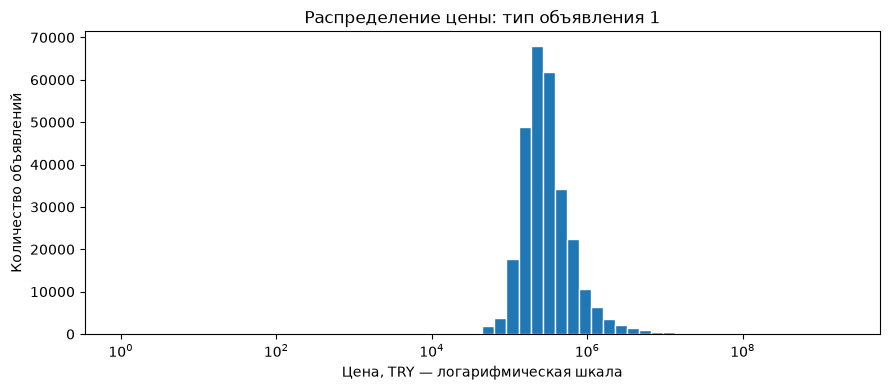

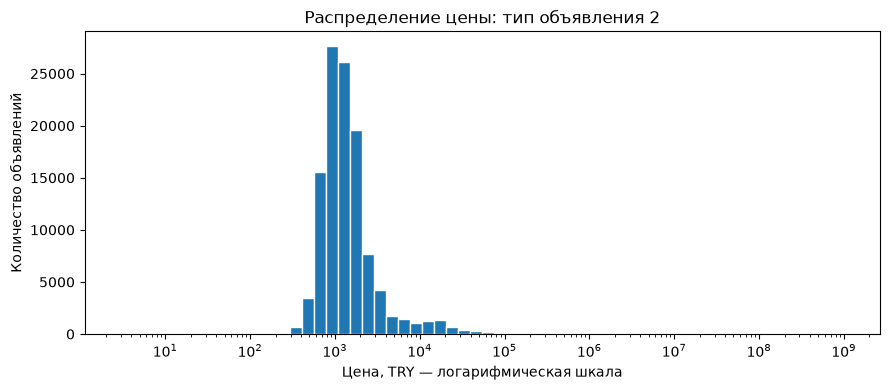

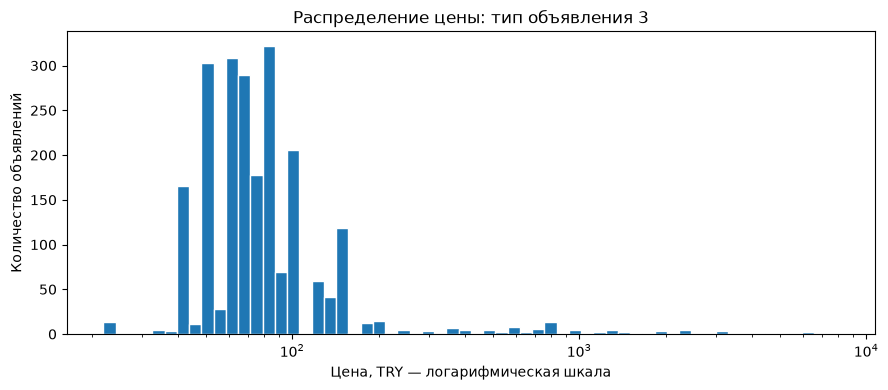

In [42]:
for listing_type, group in viz_df.groupby("listing_type"):
    prices = group["price_try"]

    # Интервалы равномерны по логарифмической шкале.
    bins = np.geomspace(prices.min(), prices.max(), 61)

    plt.figure(figsize=(9, 4))
    plt.hist(prices, bins=bins, edgecolor="white")

    plt.xscale("log")
    plt.xlabel("Цена, TRY - логарифмическая шкала")
    plt.ylabel("Количество объявлений")
    plt.title(f"Распределение цены: тип объявления {listing_type}")

    plt.tight_layout()
    plt.show()

Используются пересчитанные цены всех валют; типы объявлений разделены; весь диапазон цен сохраняется. Логарифмическая ось позволяет увидеть распределение при больших различиях цен.

 Тип 1 - самый массовый и "дорогой", тип 2 - дешевле, тип 3 - малочисленный и ненадёжный.

#### Распределение площади

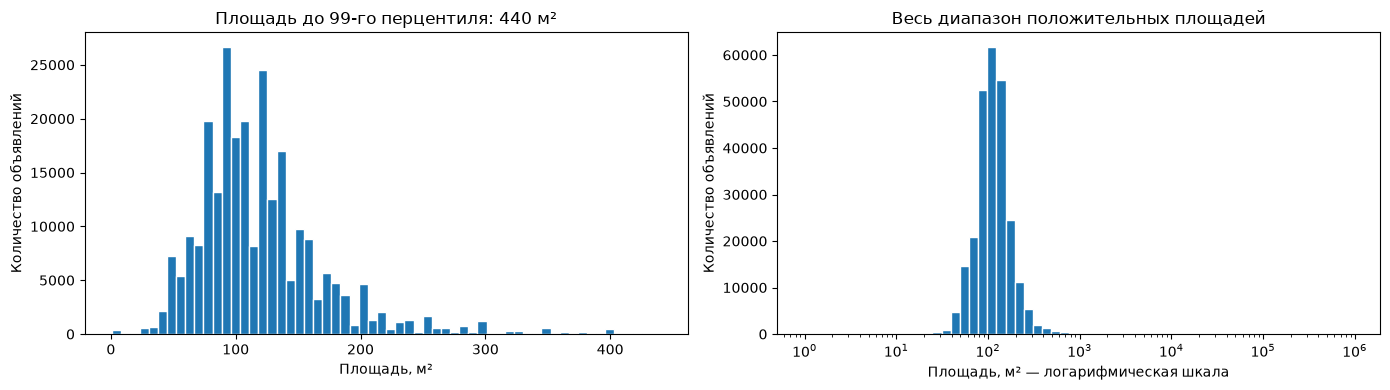

На левом графике не показаны значения выше порога: 2559


In [44]:
# Для площади берём весь набор, включая объявления без цены.
areas = df_prices["size"].dropna()
areas = areas[areas > 0]

limit = areas.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Основная часть распределения.
# Большие площади не заменяются порогом.
axes[0].hist(
    areas[areas <= limit],
    bins=60,
    edgecolor="white"
)
axes[0].set_title(f"Площадь до 99-го перцентиля: {limit:,.0f} м²")
axes[0].set_xlabel("Площадь, м²")
axes[0].set_ylabel("Количество объявлений")

# Весь диапазон положительных площадей.
bins = np.geomspace(areas.min(), areas.max(), 61)

axes[1].hist(areas, bins=bins, edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Весь диапазон положительных площадей")
axes[1].set_xlabel("Площадь, м² — логарифмическая шкала")
axes[1].set_ylabel("Количество объявлений")

plt.tight_layout()
plt.show()

print(
    "На левом графике не показаны значения выше порога:",
    int((areas > limit).sum())
)

Слева показана основная часть данных, справа - весь диапазон.

#### Количество комнат

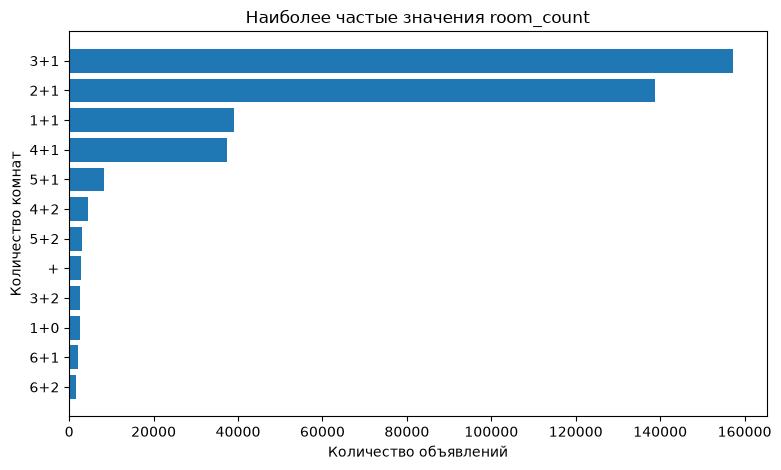

In [45]:
room_counts = df['room_count'].value_counts().head(12).sort_values()

plt.figure(figsize=(9,5))
plt.barh(room_counts.index.astype(str), room_counts.values)
plt.xlabel('Количество объявлений')
plt.ylabel('Количество комнат')
plt.title('Наиболее частые значения room_count')
plt.show()

**Вывод:** наиболее массовые типы квартир представлены несколькими повторяющимися форматами комнат.

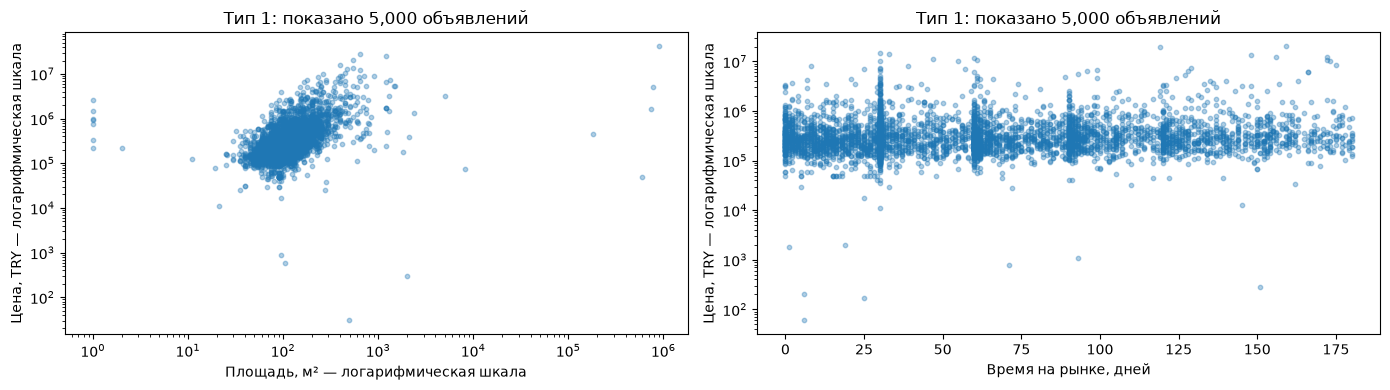

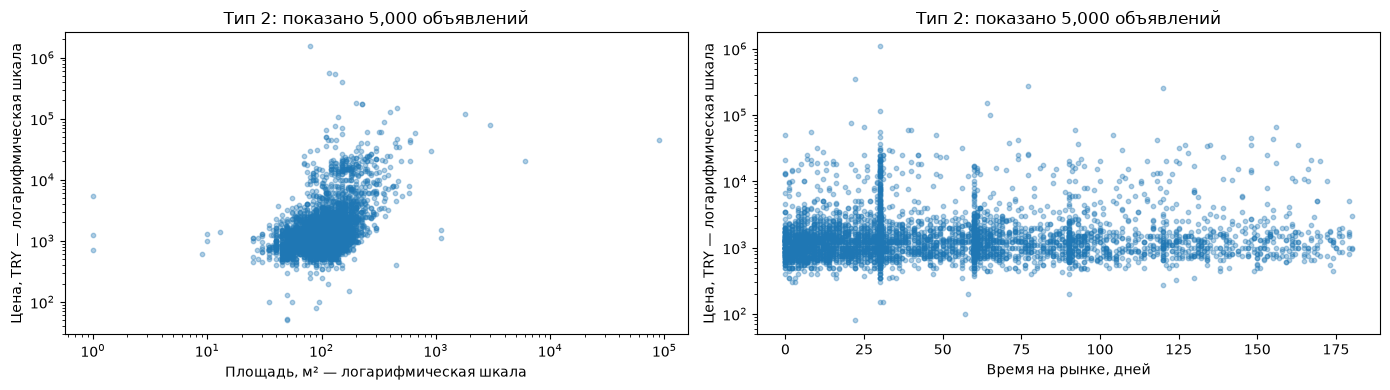

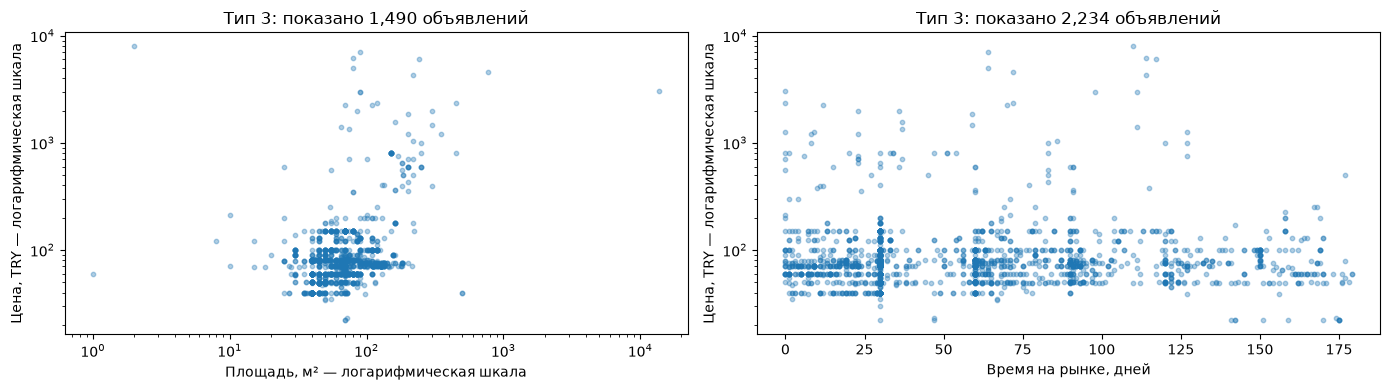

In [47]:
for listing_type, group in viz_df.groupby("listing_type"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    settings = [
        ("size", "Площадь, м² — логарифмическая шкала"),
        ("tom", "Время на рынке, дней")
    ]

    for ax, (feature, label) in zip(axes, settings):
        points = group[[feature, "price_try"]].dropna()

        if feature == "size":
            points = points.loc[points["size"] > 0]

        # Сначала выбираем подходящие строки, затем берём выборку.
        points = points.sample(
            n=min(5000, len(points)),
            random_state=42
        )

        ax.scatter(
            points[feature],
            points["price_try"],
            s=10,
            alpha=0.35
        )

        ax.set_yscale("log")

        if feature == "size":
            ax.set_xscale("log")

        ax.set_xlabel(label)
        ax.set_ylabel("Цена, TRY — логарифмическая шкала")
        ax.set_title(
            f"Тип {listing_type}: показано {len(points):,} объявлений"
        )

    plt.tight_layout()
    plt.show()

Тип 1 и тип 2: видна чёткая положительная связь - с ростом площади цена растёт. Облако точек плотное, наклонное, что подтверждает ожидаемую закономерность. 

Тип 3: связь слабая и размытая, облако точек разреженное - из-за малого числа наблюдений (1 490) и большого разброса.

#### Boxplot цены по крупнейшим подтипам недвижимости

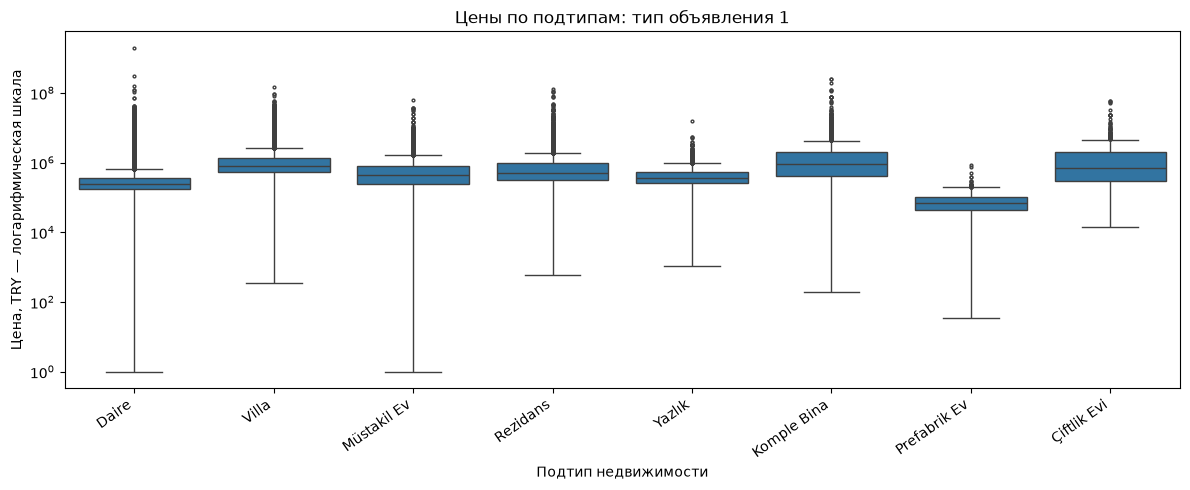

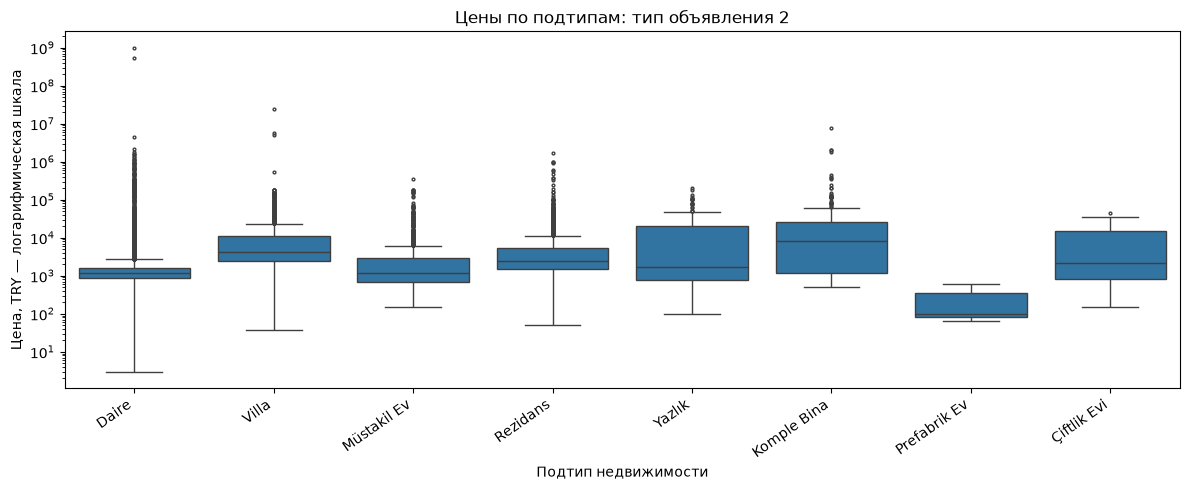

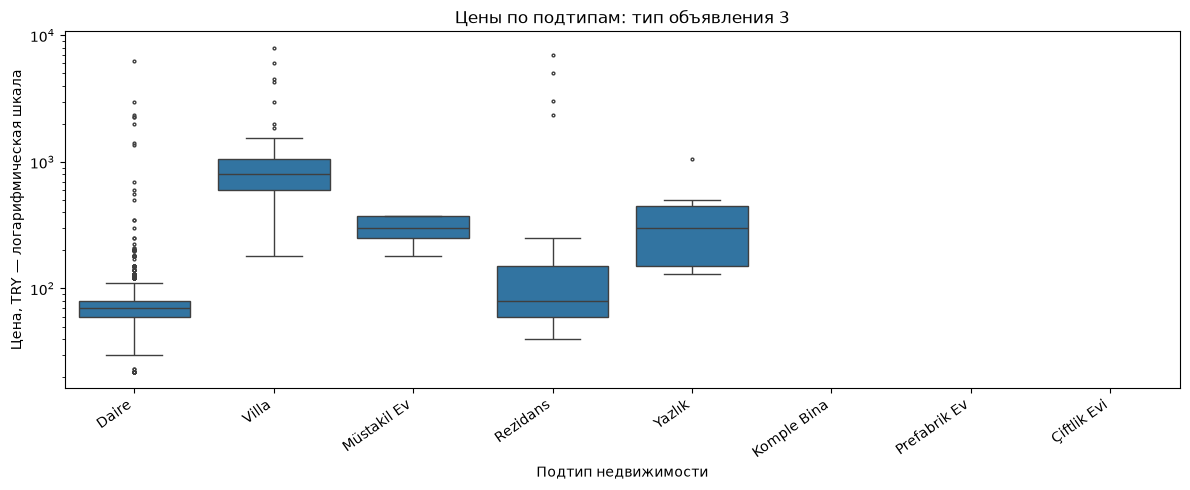

In [49]:
# Одинаковый набор подтипов для сравнения между группами.
top_subtypes = (
    viz_df["sub_type"]
    .value_counts()
    .head(8)
    .index
)

for listing_type, group in viz_df.groupby("listing_type"):
    box_data = group.loc[
        group["sub_type"].isin(top_subtypes)
    ]

    plt.figure(figsize=(12, 5))

    sns.boxplot(
        data=box_data,
        x="sub_type",
        y="price_try",
        order=top_subtypes,
        showfliers=True,
        fliersize=2
    )

    plt.yscale("log")
    plt.xticks(rotation=35, ha="right")
    plt.xlabel("Подтип недвижимости")
    plt.ylabel("Цена, TRY — логарифмическая шкала")
    plt.title(f"Цены по подтипам: тип объявления {listing_type}")

    plt.tight_layout()
    plt.show()

Тип объявления сильно влияет на уровень цен: тип 1 > тип 2 > тип 3 по медиане.

Подтип недвижимости — тоже значимый признак: Çiftlik Evi и Köyde Villa стабильно дороже, Prefabrik Ev — дешевле.

Выбросы присутствуют везде

Boxplot рассчитывается по исходным пересчитанным значениям, выбросы показываются.

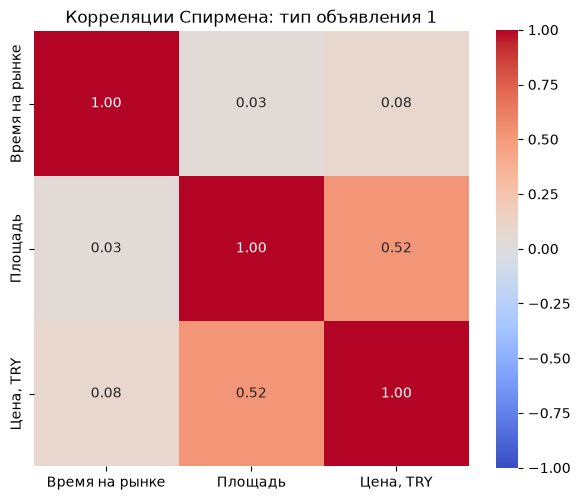

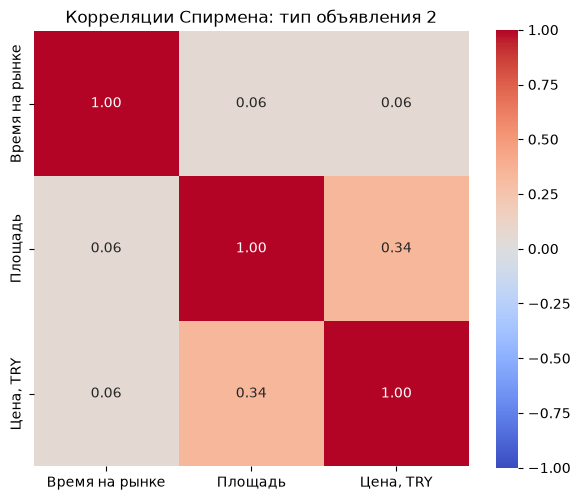

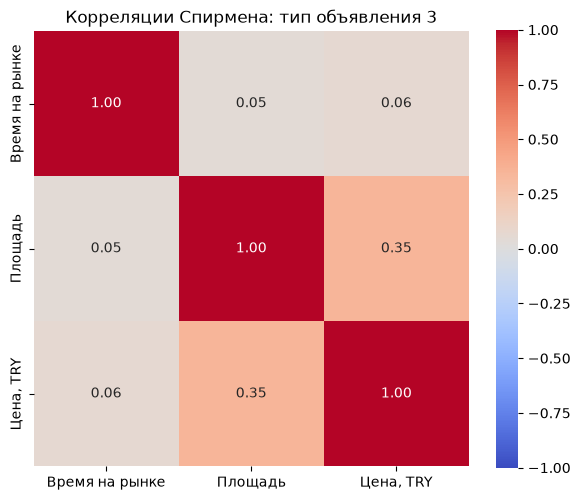

In [51]:
column_labels = {
    "tom": "Время на рынке",
    "size": "Площадь",
    "price_try": "Цена, TRY"
}

for listing_type, group in viz_df.groupby("listing_type"):
    corr = (
        group[["tom", "size", "price_try"]]
        .rename(columns=column_labels)
        .corr(method="spearman")
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        vmin=-1,
        vmax=1,
        center=0,
        square=True
    )

    plt.title(f"Корреляции Спирмена: тип объявления {listing_type}")
    plt.tight_layout()
    plt.show()

Площадь - Цена — единственная заметная связь:

Тип 1: 0.52 — умеренная положительная корреляция (самая сильная из всех).

Тип 2 и 3: 0.34–0.35 — слабая/умеренная, но устойчивая.

Здесь используются содержательные числовые характеристики и пересчитанная цена. Выбран коэффициент Спирмена: он оценивает монотонную связь и менее чувствителен к величине экстремальных значений. Корреляция показывает связь, но сама по себе не доказывает влияние одного признака на другой.

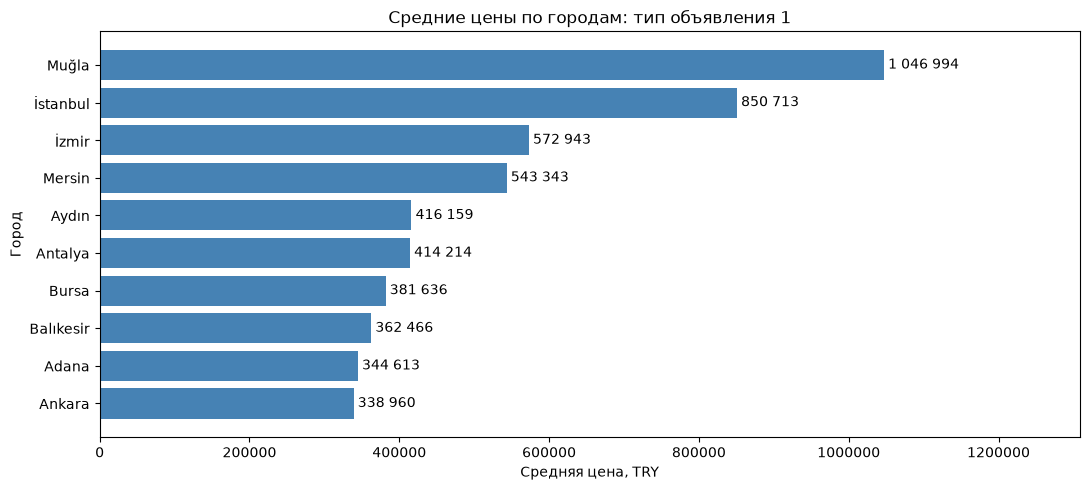

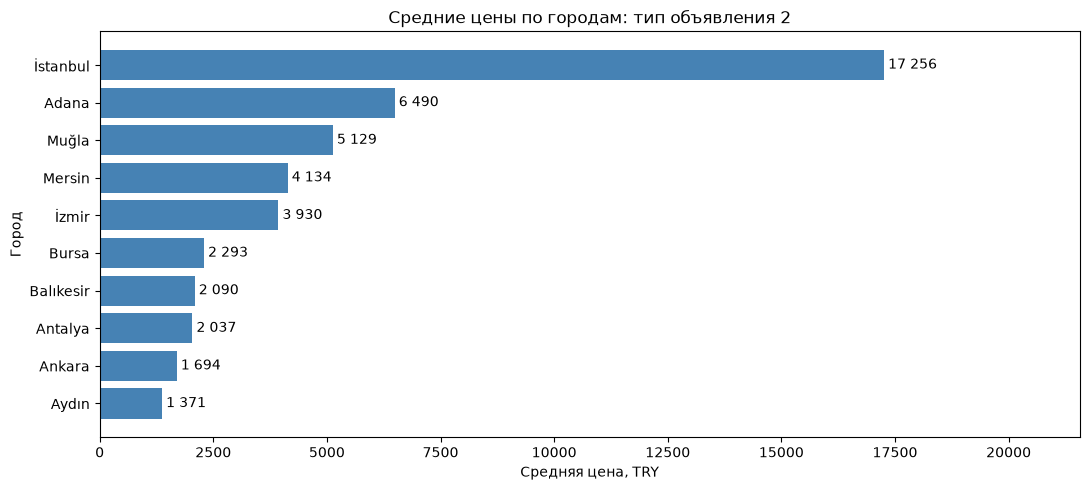

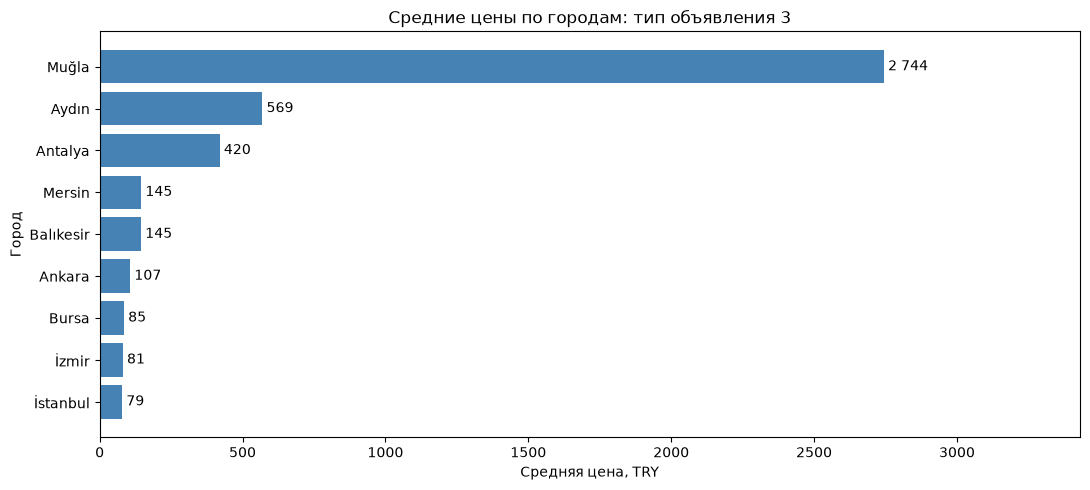

In [53]:
# Выбираем одни и те же города для всех типов объявлений.
top_cities = (
    viz_df["city"]
    .value_counts()
    .head(10)
    .index
)

for listing_type, group in viz_df.groupby("listing_type"):
    city_price = (
        group.loc[group["city"].isin(top_cities)]
        .groupby("city")["price_try"]
        .mean()
        .sort_values()
    )

    if city_price.empty:
        continue

    fig, ax = plt.subplots(figsize=(11, 5))

    bars = ax.barh(
        city_price.index,
        city_price.values,
        color="steelblue"
    )

    # Подписываем значения, чтобы их было удобно читать.
    ax.bar_label(
        bars,
        labels=[
            f"{value:,.0f}".replace(",", " ")
            for value in city_price.values
        ],
        padding=3
    )

    ax.margins(x=0.25)
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.set_xlabel("Средняя цена, TRY")
    ax.set_ylabel("Город")
    ax.set_title(f"Средние цены по городам: тип объявления {listing_type}")

    plt.tight_layout()
    plt.show()

Muğla - стабильно дорогой город во всех трёх типах (курортный регион).

### 1.4 Анализ пропусков и аномалий

In [54]:
df.isna().sum()

id                        0
type                      0
sub_type                  0
start_date                0
end_date             137189
listing_type              0
tom                       0
building_age          27390
total_floor_count     28021
floor_no              35296
room_count                0
size                 146006
address                   0
furnished            403487
heating_type          27970
price                   715
price_currency          715
dtype: int64

In [55]:
missing_table = pd.DataFrame({
    "Количество пропусков": df.isna().sum(),
    "Доля пропусков, %": (df.isna().mean() * 100).round(2)
}).sort_values("Количество пропусков", ascending=False)

display(missing_table)

,Количество пропусков,"Доля пропусков, %"
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
price_currency,715,0.18
price,715,0.18
id,0,0.00


Таблица показывает и количество, и процент пропусков для каждого столбца, включая столбцы без пропусков. В исходном наборе пропуски присутствуют в 9 из 17 столбцов. Полностью отсутствуют значения furnished - 100%. Значительная доля пропусков выявлена в size - 36,19%, end_date - 34,00% и floor_no - 8,75%.

Вывод: пропуски особенно важны для признаков площади, возраста здания, этажности и отопления. Столбец **furnished** не содержит полезной информации, если он полностью пуст.

### Проверка дубликатов

In [56]:
print('Количество полных дубликатов:', df.duplicated().sum())

Количество полных дубликатов: 0


In [57]:
comparison_cols = [
    col for col in df.columns
    if col != "id"
]

print(
    "Повторных строк без учёта id:",
    df.duplicated(subset=comparison_cols).sum()
)

Повторных строк без учёта id: 11559


Полных дубликатов с учётом всех столбцов не обнаружено. Однако без учёта уникального id найдено 11 559 повторных строк. Эти совпадения требуют дополнительной проверки перед решением об удалении.

### Проверка логических аномалий

In [59]:
# Временные числовые значения только для проверки
floor_num = pd.to_numeric(df["floor_no"], errors="coerce")
total_floors_num = pd.to_numeric(
    df["total_floor_count"],
    errors="coerce"
)

anomaly_counts = pd.Series({
    "Отрицательная цена":
        (df["price"] < 0).sum(),

    "Нулевая цена":
        (df["price"] == 0).sum(),

    "Нулевая или отрицательная площадь":
        (df["size"] <= 0).sum(),

    "Площадь меньше 10 м²":
        (df["size"] < 10).sum(),

    "Площадь больше 10 000 м²":
        (df["size"] > 10000).sum(),

    "Количество комнат указано как +":
        df["room_count"].eq("+").sum(),

    "Этаж превышает этажность здания":
        (floor_num > total_floors_num).sum()
}, name="Количество строк")

display(anomaly_counts)

Отрицательная цена                      1
Нулевая цена                           44
Нулевая или отрицательная площадь       0
Площадь меньше 10 м²                  389
Площадь больше 10 000 м²              148
Количество комнат указано как +      2898
Этаж превышает этажность здания      1387
Name: Количество строк, dtype: int64

**Вывод:** обнаружены 1 отрицательная и 44 нулевые цены. Их необходимо обработать до моделирования. Нулевых/отрицательных площадей нет, но есть 148 объектов с площадью более 10 000 м кв - это потенциальные аномалии, требующие проверки, а не автоматического удаления. `tom` находится в ожидаемом диапазоне 0–180 дней.


### 1.5 Промежуточные выводы и гипотезы

#### Основные выводы

Исследован набор из 403 487 объявлений. Для сопоставления цен разных валют выполнен исторический пересчёт в турецкие лиры. Анализ положительных цен проведён отдельно для трёх значений `listing_type`.

По результатам визуального и корреляционного анализа сформулированы следующие гипотезы.

1. **Большая площадь связана с более высокой ценой.**  
   Гипотеза поддерживается диаграммами «Площадь - цена» и положительными коэффициентами Спирмена: около 0,52 для типа 1, 0,34 для типа 2 и 0,35 для типа 3. Выраженность связи различается между группами.

2. **Уровень цены различается между подтипами недвижимости.**  
   На boxplot для типа 1 медианные цены `Villa` и `Komple Bina` выше, чем у `Daire`. Это поддерживает предположение о связи подтипа с ценой. Различия могут частично объясняться площадью и местоположением объектов; отдельный эффект подтипа пока не оценивался.

3. **Местоположение связано с уровнем цены.**  
   Среди показанных городов для типа 1 средняя цена составляет примерно 1 046 994 TRY в Muğla и 338 960 TRY в Ankara. Наблюдаемые различия поддерживают гипотезу, но могут зависеть от состава объектов и экстремальных цен. Они не доказывают самостоятельное влияние города.

4. **Время нахождения на рынке имеет сильную монотонную связь с ценой.**  
   Эта гипотеза не получила поддержки: коэффициенты Спирмена составляют около 0,08, 0,06 и 0,06 для типов 1, 2 и 3 соответственно. Наблюдаемая монотонная связь слабая. Это не исключает нелинейных зависимостей или полезности признака в сочетании с другими характеристиками.

Площадь, подтип и местоположение представляют интерес для дальнейшего моделирования. Перед обучением необходимо выбрать способы обработки пропусков, повторов и подозрительных значений. Выявленные статистические связи не являются доказательством причинного влияния признаков на цену.

### *Этап 2. Предварительная обработка данных*

### 2.1 Работа с пропусками

In [61]:
from sklearn.impute import SimpleImputer

In [62]:
# Целевая переменная — цена в турецких лирах
target = "price_try"

In [63]:
# Берём все типы объявлений
df_stage2 = df_prices.copy()

In [64]:
# Учитываем скрытый пропуск в количестве комнат
df_stage2["room_count"] = (
    df_stage2["room_count"].replace("+", pd.NA)
)

In [65]:
# Исключаем строки, в которых неизвестна целевая цена
missing_target_count = df_stage2[target].isna().sum()

df_stage2 = (
    df_stage2
    .dropna(subset=[target])
    .copy()
)

In [66]:
# Удаляем полностью пустой столбец
df_stage2 = df_stage2.drop(columns=["furnished"])

Для обработки пропусков создана отдельная рабочая таблица df_stage2, содержащая объявления всех типов с известной целевой ценой в турецких лирах. Строки без целевой цены исключены из данных для обучения: заполнение таких значений означало бы создание искусственных ответов для модели. Полностью незаполненный признак furnished удалён.

In [67]:
# Заполняем пропуски в категориальных характеристиках
categorical_missing_cols = [
    "building_age",
    "total_floor_count",
    "floor_no",
    "heating_type",
    "room_count"
]

df_stage2[categorical_missing_cols] = (
    df_stage2[categorical_missing_cols]
    .fillna("Не указано")
)

Пропуски в категориальных характеристиках заменены значением «Не указано». Значение «+» в room_count также отнесено к отсутствующей информации, поскольку оно не позволяет определить количество комнат.

На этом шаге отсутствие категориальной информации обозначено значением «Не указано», которое сохраняется в рабочей таблице df_clean.

При дальнейшем кодировании номинальных признаков это значение рассматривается как отдельная категория. Для порядковых признаков building_age и total_floor_count применяется другая схема: неизвестное значение заменяется наиболее частым известным рангом обучающей выборки, а отдельный индикатор сохраняет информацию о первоначальном пропуске. Все обучаемые параметры этой обработки определяются только по train.

In [68]:
# Подготавливаем обработчик пропусков площади
# Обучим его только на train после разбиения в пункте 2.6
size_imputer = SimpleImputer(strategy="median")

Для площади выбран метод заполнения медианой. Он позволяет сохранить строки с неизвестной площадью и уменьшает влияние экстремальных значений на величину заполнения. Медиана будет рассчитана только на обучающей выборке после разбиения данных в пункте 2.6.

In [69]:
# end_date не заполняем произвольными датами.

print( "Исключено строк без целевой цены:",int(missing_target_count))
print("Осталось строк:", len(df_stage2))
missing_after = pd.DataFrame({ "Количество пропусков": df_stage2.isna().sum(),"Доля пропусков, %": ( df_stage2.isna().mean() * 100 ).round(2)})

display( missing_after.loc[missing_after["Количество пропусков"] > 0 ])

Исключено строк без целевой цены: 715
Осталось строк: 402772


,Количество пропусков,"Доля пропусков, %"
end_date,136474,33.88
size,145392,36.10


Пропуски в end_date сохранены, поскольку неизвестную дату окончания объявления нельзя достоверно восстановить. Этот столбец не будет использоваться как входной признак модели, прогнозирующей цену нового объявления.

### 2.2 Обработка выбросов

In [70]:
df_clean = df_stage2.copy()

In [71]:
# Недопустимые цены: неположительные или бесконечные
inv_price = ((df_clean["price_try"] <= 0) | ~np.isfinite(df_clean["price_try"]))

In [72]:
removed_price_count = int(inv_price.sum())

In [73]:
df_clean = df_clean.loc[~inv_price].copy()

In [74]:
# Некорректную площадь считаем неизвестной
# Уже существующие пропуски сохраняем
inv_size = (df_clean["size"].notna()& ((df_clean["size"] <= 0) | ~np.isfinite(df_clean["size"]) ))

In [75]:
inv_size_count = int(inv_size.sum())
df_clean.loc[inv_size, "size"] = np.nan

In [76]:
print("Исключено строк с недопустимой ценой:",removed_price_count)
print("Некорректных площадей заменено на пропуск:",inv_size_count)
print("Осталось строк:", len(df_clean))

display( df_clean["listing_type"].value_counts().sort_index().rename("Количество объявлений"))

Исключено строк с недопустимой ценой: 45
Некорректных площадей заменено на пропуск: 0
Осталось строк: 402727


listing_type
1    286392
2    114101
3      2234
Name: Количество объявлений, dtype: int64

Из рабочей выборки исключены 45 объявлений с неположительной ценой, поскольку такие значения не подходят для прогнозирования положительной стоимости недвижимости. После исключения осталось 402 727 объявлений всех трёх типов.

In [77]:
#np.log1p(x) вычисляет ln(1 + x).
skewness_rows = []
# Сравниваем распределения отдельно по типам объявлений.
for listing_type, group in df_clean.groupby("listing_type"):
    for feature in ["price_try", "size"]:
        values = group[feature].dropna()
        log_values = np.log1p(values)

        skewness_rows.append({
            "Тип объявления": listing_type,
            "Признак": feature,
            "Количество значений": len(values),
            "Асимметрия до": values.skew(),
            "Асимметрия после log1p": log_values.skew()})

skewness_comparison = pd.DataFrame(skewness_rows)
display(skewness_comparison.round(2))

,Тип объявления,Признак,Количество значений,Асимметрия до,Асимметрия после log1p
0,1,price_try,286392,289.90,0.66
1,1,size,184690,66.23,2.20
2,2,price_try,114101,268.71,2.23
3,2,size,71195,245.96,-0.22
4,3,price_try,2234,13.12,3.02
5,3,size,1490,37.61,0.92


Для цены и площади проверено логарифмическое преобразование ln(1 + x). Его эффект оценён по изменению асимметрии отдельно внутри каждого типа объявления. Логарифмирование рассматривается как способ уменьшения различий в масштабе значений; оно не подтверждает достоверность подозрительных записей и не гарантирует улучшения модели.

В базовом варианте обработки большие положительные цены и площади сохранены: экстремальная величина сама по себе не доказывает ошибку в объявлении. Винсоризация на данном шаге не применяется, поскольку обоснованные пороги ограничения ещё не определены.

Сравнение показало уменьшение абсолютной величины асимметрии после логарифмирования во всех рассмотренных группах. Поэтому логарифмирование выбрано для дальнейшей проверки при моделировании. Для площади оно будет выполняться после заполнения пропусков медианой обучающей выборки. Влияние преобразований на качество прогнозирования будет оценено на валидации.

### 2.3 Кодирование категориальных признаков

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [79]:
nominal_cols = [
    "listing_type",
    "sub_type",
    "heating_type",
    "floor_no",
    "room_count"
]

In [80]:
# Упорядоченные категории
ordinal_cols = [ "building_age","total_floor_count"]

In [81]:
# Признак с большим количеством категорий
address_cols = ["address"]

In [82]:
# Порядок возрастных категорий
age_order = [
    "0", "1", "2", "3", "4", "5",
    "6-10 arası",
    "11-15 arası",
    "16-20 arası",
    "21-25 arası",
    "26-30 arası",
    "31-35 arası",
    "36-40 arası",
    "40 ve üzeri"
]

In [83]:
# Порядок категорий этажности
floors_order = [
    "1", "2", "3", "4", "5",
    "6", "7", "8", "9", "10",
    "10-20 arası",
    "20 ve üzeri"
]

In [84]:
# Проверяем, что все известные порядковые категории учтены
for column, order in zip(
    ordinal_cols,
    [age_order, floors_order]): 
    unexpected = (set(df_clean[column].dropna().unique()) - set(order) - {"Не указано"} )
    if unexpected:
        raise ValueError(
            f"В столбце {column} найдены категории "
            f"вне заданного порядка: {unexpected}")
categorical_cols = (nominal_cols + ordinal_cols + address_cols)
display(df_clean[categorical_cols].nunique().rename("Количество категорий").to_frame())
print("Порядковые категории проверены")

,Количество категорий
listing_type,3
sub_type,12
heating_type,17
floor_no,36
room_count,37
building_age,15
total_floor_count,13
address,7833


Порядковые категории проверены


Для building_age и total_floor_count задано порядковое кодирование с явной последовательностью категорий. Полученные значения являются рангами и не интерпретируются как точный возраст или количество этажей. Для отсутствующих и неизвестных категорий предусмотрено заполнение наиболее частым известным рангом обучающей выборки с добавлением индикатора пропуска.

In [85]:
# Кодирование номинальных признаков
nominal_encoder = OneHotEncoder(handle_unknown="ignore",drop="first",sparse_output=True)

Для номинальных признаков выбран One-Hot Encoding. Значения listing_type рассматриваются как названия групп, а не количественные величины. Обозначения этажа кодируются номинально, поскольку среди них присутствуют текстовые категории, для которых не задан единый содержательный порядок. 

In [86]:
# Кодирование порядковых признаков
# и обработка отсутствующих/неизвестных категорий
ordinal_pipeline = Pipeline([
    ("encode",OrdinalEncoder(categories=[age_order, floors_order],handle_unknown="use_encoded_value",unknown_value=np.nan,dtype=np.float64)),
    ( "fill",SimpleImputer(strategy="most_frequent",add_indicator=True) )])

In [87]:
# Редкие адресные категории объединяются внутри кодера
address_encoder = OneHotEncoder(min_frequency=20,handle_unknown="infrequent_if_exist",drop="first",sparse_output=True)

Для address выбрано объединение категорий, встречающихся менее 20 раз в обучающей выборке, с последующим One-Hot Encoding. Это уменьшает размерность, но приводит к потере части различий между редкими адресами. Порог является начальной настройкой и может быть пересмотрен по результатам валидации.

In [88]:
# Объединяем обработку категориальных признаков
categorical_preprocessor = ColumnTransformer(
    transformers=[("nominal", nominal_encoder, nominal_cols),("ordinal", ordinal_pipeline, ordinal_cols),("address", address_encoder, address_cols)],
    remainder="drop",sparse_threshold=1.0)

In [89]:
print("Кодеры подготовлены, обучение будет выполнено на train в пункте 2.6.")

Кодеры подготовлены, обучение будет выполнено на train в пункте 2.6.


На данном шаге подготовлены правила и обработчик категориальных признаков. Его обучение будет выполнено только на train после разбиения данных. При кросс-валидации обработчик будет включён в Pipeline, чтобы обучаться внутри каждой обучающей части.

### 2.4 Работа с Feature Engineering

In [90]:
def add_model_features(data):
    result = data.copy()

    # Разбираем планировку вида "2+1".
    # Первое число - комнаты, второе — гостиные
    room_parts = (
        result["room_count"].astype("string").str.extract(r"^\s*(\d+)\s*\+\s*(\d+)\s*$").apply(pd.to_numeric, errors="coerce").astype(float))

    result["rooms_total"] = room_parts[0] + room_parts[1]
    result["living_rooms"] = room_parts[1]

    # Нераспознанную планировку и "0+0" считаем неизвестными
    inv_rooms = (room_parts.isna().any(axis=1) | result["rooms_total"].le(0))

    result.loc[inv_rooms,["rooms_total", "living_rooms"]] = np.nan

    # Один общий индикатор для двух признаков планировки
    result["rooms_missing"] = inv_rooms.astype("int8")

    # Время публикации относительно фиксированной даты
    start_dates = pd.to_datetime(result["start_date"],format="%m/%d/%y",errors="raise" )

    result["listing_time_days"] = (start_dates - pd.Timestamp("2018-01-01") ).dt.days
    return result


df_features = add_model_features(df_clean)
display(df_features[["room_count", "rooms_total", "living_rooms","rooms_missing", "start_date", "listing_time_days"]].head(10))

print("Неизвестная или неинформативная планировка:",int(df_features["rooms_missing"].sum()))

,room_count,rooms_total,living_rooms,rooms_missing,start_date,listing_time_days
0,2+1,3.0,1.0,0,12/10/18,343
1,1+0,1.0,0.0,0,2/13/19,408
2,2+1,3.0,1.0,0,10/9/18,281
3,6+1,7.0,1.0,0,9/10/18,252
4,2+1,3.0,1.0,0,12/10/18,343
5,1+1,2.0,1.0,0,11/9/18,312
6,3+1,4.0,1.0,0,1/4/19,368
7,4+1,5.0,1.0,0,10/3/18,275
8,3+1,4.0,1.0,0,2/16/19,411
9,2+2,4.0,2.0,0,12/26/18,359


Неизвестная или неинформативная планировка: 2308


Созданы четыре новых признака:

- `rooms_total` - общее количество комнат, включая гостиные;
- `living_rooms` - количество гостиных;
- `rooms_missing` - индикатор неизвестной или неинформативной планировки;
- `listing_time_days` - количество дней от фиксированной даты 01.01.2018 до начала публикации объявления.

Например, обозначение `2+1` преобразуется в три комнаты, включая одну гостиную. Первое число не интерпретируется как количество спален.

Нераспознанная планировка и обозначение `0+0` считаются неизвестными: числовые характеристики комнат получают пропуски, а индикатор - значение 1. Объявления сохраняются. Ноль гостиных в планировке `1+0` допустим.

Пропуски числовых характеристик комнат будут заполняться наиболее частыми значениями обучающей выборки после разбиения данных. Индикатор сохранит информацию о первоначальном отсутствии планировки.

Временной признак доступен при размещении объявления. Все новые признаки вычисляются без использования цены и без расчёта общих статистик по набору данных.

In [91]:
numeric_cols = ["size","rooms_total","living_rooms","listing_time_days"]

In [92]:
binary_cols = ["rooms_missing"]

In [93]:
# room_count заменён числовыми характеристиками планировки
nominal_cols = ["listing_type","sub_type","heating_type","floor_no"]

In [94]:
# ordinal_cols и address_cols уже определены в пункте 2.3
categorical_cols = nominal_cols + ordinal_cols + address_cols

In [95]:
feature_cols = numeric_cols + binary_cols + categorical_cols

In [96]:
X = df_features[feature_cols].copy()
y = df_features["price_try"].copy()

In [97]:
excluded_cols = [
    col for col in df_features.columns
    if col not in feature_cols and col != "price_try"]

In [98]:
# Проверяем соответствие строк и отсутствие цены среди входов.
assert X.index.equals(y.index)

In [99]:
assert not {"price", "price_try", "price_rub", "end_date", "tom"} & set(X.columns)

In [100]:
assert y.notna().all() and np.isfinite(y).all() and y.gt(0).all()

In [101]:
print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Не используются как входы модели:", excluded_cols)

display( X.isna().sum().rename("Количество пропусков"))

Размер X: (402727, 12)
Размер y: (402727,)
Не используются как входы модели: ['id', 'type', 'start_date', 'end_date', 'tom', 'room_count', 'price', 'price_currency', 'price_rub']


size                 145352
rooms_total            2308
living_rooms           2308
listing_time_days         0
rooms_missing             0
listing_type              0
sub_type                  0
heating_type              0
floor_no                  0
building_age              0
total_floor_count         0
address                   0
Name: Количество пропусков, dtype: int64

Для моделирования сформирована таблица входных признаков X. Целевая переменная price_try выделена отдельно в y. Сохраняются объявления всех трёх типов.

При выборе входов учитывается сценарий прогнозирования цены в момент размещения нового объявления.

Исходная планировка и её числовые производные не включаются в модель одновременно, чтобы избежать дублирования информации и возможных линейных зависимостей. Полный адрес сохраняется как один категориальный признак; дополнительные вложенные адресные признаки в базовую схему не добавляются. Исключение из X не удаляет исходные сведения из рабочих таблиц, используемых для проверки данных.
Из входов модели исключены:

- id — технический идентификатор;
- type — признак с одним значением в текущем наборе;
- price и price_rub — исходная цена и её пересчитанный эквивалент, содержащие информацию о целевом ответе;
- end_date и tom — окончание публикации и итоговая длительность размещения, неизвестные в момент появления нового объявления;
- room_count — заменён числовыми характеристиками планировки и индикатором отсутствующей информации;
- start_date — представлен числовым признаком времени публикации.

price_currency используется для пересчёта целевой цены, но в выбранном базовом варианте не включается во входы модели. Сама по себе валюта не является утечкой целевой цены.
Целевая переменная price_try хранится отдельно в y. Полностью пустой столбец furnished удалён на предыдущем шаге.

Теперь room_count отсутствует в списке категориальных входов. Поэтому нужно пересоздать обработчик с обновлённым списком

In [102]:
categorical_preprocessor = ColumnTransformer(transformers=[("nominal", nominal_encoder, nominal_cols),("ordinal", ordinal_pipeline, ordinal_cols),
        ("address", address_encoder, address_cols)], remainder="drop",sparse_threshold=1.0)

Категориальный обработчик обновлён, обучение - после разбиения

In [103]:
from statsmodels.stats.outliers_influence import (variance_inflation_factor)
from statsmodels.tools.tools import add_constant

VIF помогает выявить признаки, которые хорошо выражаются через другие входы линейной модели.

In [104]:
def calculate_vif(train_numeric):
    table = train_numeric.astype(float).copy()

    if not np.isfinite(table.to_numpy()).all():
        raise ValueError("Для VIF нужны числовые данные ""без пропусков и бесконечностей.")

    constant_cols = table.columns[table.nunique() <= 1].tolist()

    if constant_cols:
        raise ValueError(f"Сначала исключите константные признаки: {constant_cols}")

    # Свободный член нужен для вспомогательных регрессий
    design = add_constant(table, has_constant="add")

    return pd.DataFrame({
        "Признак": table.columns,
        "VIF": [
            variance_inflation_factor(
                design.to_numpy(), i + 1
            )
            for i in range(table.shape[1])]}).sort_values("VIF", ascending=False)

Функция VIF подготовлена. Расчёт выполним на train в пункте 2.6.

На этапе формирования входов исключены неинформативные признаки и очевидное дублирование исходных и производных характеристик.

Для дальнейшей проверки мультиколлинеарности подготовлена функция расчёта VIF. Она будет применена к числовой части обучающей выборки после заполнения пропусков и выбранных преобразований. В проверку будут включены используемые числовые признаки, порядковые коды и индикаторы пропусков. Целевая цена в расчёт не включается.

До получения результатов нельзя утверждать, что мультиколлинеарность полностью устранена. Высокие значения VIF потребуют рассмотрения зависимых признаков и обоснования дальнейшего отбора.

Дополнительное уменьшение размерности, например PCA, на данном шаге не применяется. Для адресов уже предусмотрено объединение редких категорий. Необходимость дальнейшего сокращения будет оцениваться после формирования обучающей матрицы с учётом её размера и результатов моделирования.

### 2.5 Масштабирование признаков

Подготовлены два варианта обработки: с масштабированием для линейных моделей и без масштабирования для моделей на основе деревьев.

Для линейных моделей выбрана следующая схема:

- size - Заполнение медианой - log1p - RobustScaler
- rooms_total, living_rooms - Заполнение наиболее частыми значениями  StandardScaler
- listing_time_days - StandardScaler
- Ранги возраста здания и этажности - Кодирование и заполнение пропусков  StandardScaler
- Индикаторы пропусков и One-Hot-признаки - Сохранение значений 0/1

Для площади выбран RobustScaler, поскольку его параметры рассчитываются по медиане и межквартильному размаху и меньше зависят от экстремальных значений. Само масштабирование не удаляет выбросы.

Количество комнат, дата публикации и порядковые коды приводятся к сопоставимому масштабу с помощью StandardScaler, использующего среднее и стандартное отклонение обучающей выборки.

MinMaxScaler в базовой схеме не используется: он зависит от крайних значений, из-за которых основная масса наблюдений может оказаться в узком интервале.

Для деревьев сохраняются заполнение пропусков, кодирование и выбранное преобразование площади, но шаги масштабирования отключаются. Логарифмирование площади остаётся вариантом для проверки при моделировании; его преимущество заранее не утверждается.

In [105]:
from sklearn.base import clone
from sklearn.preprocessing import (StandardScaler,RobustScaler,FunctionTransformer)

In [106]:
def make_preprocessor(scale_numeric=True):
    # Площадь: медиана - логарифмирование - масштабирование
    size_pipeline = Pipeline([
        ("impute", clone(size_imputer)),
        ("log", FunctionTransformer(np.log1p,feature_names_out="one-to-one")),
        ("scale",RobustScaler() if scale_numeric else "passthrough") ])

    # Числовые характеристики комнат
    # Общий индикатор пропуска уже есть в rooms_missing
    rooms_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("scale",StandardScaler() if scale_numeric else "passthrough")])

    # Первые два выхода ordinal_pipeline — ранги
    # Остальные выходы — индикаторы пропусков
    if scale_numeric:
        ordinal_block = Pipeline([
            ("encode_fill", clone(ordinal_pipeline)),
            ("scale", ColumnTransformer(transformers=[ ("ranks", StandardScaler(), [0, 1])],remainder="passthrough",verbose_feature_names_out=False))])
    else:
        ordinal_block = clone(ordinal_pipeline)

    # Сохраняем настройки кодирования из предыдущих пунктов
    category_block = clone(categorical_preprocessor)
    category_block.set_params(ordinal=ordinal_block)

    # Объединяем обработку всех входных признаков
    return ColumnTransformer(
        transformers=[("size", size_pipeline, ["size"]),
            ("rooms", rooms_pipeline,
             ["rooms_total", "living_rooms"]),
            ("time",StandardScaler() if scale_numeric else "passthrough",
             ["listing_time_days"]),
            ("binary", "passthrough", binary_cols),
            ("categories", category_block, categorical_cols)],remainder="drop",sparse_threshold=1.0)

In [107]:
preprocessor_linear = make_preprocessor(scale_numeric=True)
preprocessor_tree = make_preprocessor(scale_numeric=False)

In [108]:
# Проверяем, что каждый входной столбец включён ровно один раз
used_cols = [col for _, _, columns in preprocessor_linear.transformers for col in columns]
assert len(used_cols) == len(set(used_cols))
assert set(used_cols) == set(X.columns)

print("Входных признаков до кодирования:", len(used_cols))
print("Обработка для линейных моделей и деревьев подготовлена")

Входных признаков до кодирования: 12
Обработка для линейных моделей и деревьев подготовлена


Созданы два общих обработчика: preprocessor_linear для линейных моделей и preprocessor_tree для моделей на основе деревьев. Каждый обработчик объединяет заполнение пропусков, преобразование площади, кодирование категорий и выбранные действия с масштабом признаков.

Числовые признаки масштабируются до объединения с One-Hot-признаками. Это позволяет сохранить разреженное представление итоговой матрицы и избежать её полного преобразования в плотный массив.

На данном шаге обработчики только настроены. Медианы, моды, параметры масштабирования и частоты категорий будут определяться исключительно по обучающей выборке. При кросс-валидации обработка будет включена в общий Pipeline с моделью и обучаться заново внутри каждой обучающей части.

Исходная таблица X пока сохраняет непреобразованные значения и пропуски. Целевая переменная y остаётся ценой в турецких лирах. Логарифмирование целевой цены, если оно будет использоваться, будет организовано отдельно от обработки входных признаков.

### 2.6 Разбиение данных

Группы определяем по исходному df, до заполнения пропусков и кодирования.

In [109]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from scipy.sparse import issparse

In [110]:
random_state = 42

In [111]:
# Исходные характеристики и дата начала объявления
# Цена и сведения об окончании публикации не используются
group_cols = [
    "sub_type",
    "start_date",
    "listing_type",
    "building_age",
    "total_floor_count",
    "floor_no",
    "room_count",
    "size",
    "address",
    "heating_type"]

In [112]:
raw_rows = df.loc[X.index, group_cols]

In [113]:
groups = (raw_rows.groupby(group_cols, dropna=False, sort=False).ngroup().rename("group_id"))

In [114]:
assert X.index.equals(y.index)
assert X.index.equals(groups.index)

Выполняем разбиение и проверяем отсутствие пересечений.

In [115]:
splitter = GroupShuffleSplit( n_splits=1,test_size=0.20,random_state=random_state)

In [116]:
train_pos, test_pos = next(splitter.split(X, groups=groups))

In [117]:
X_train = X.iloc[train_pos].copy()
X_test = X.iloc[test_pos].copy()

In [118]:
y_train = y.iloc[train_pos].copy()
y_test = y.iloc[test_pos].copy()

In [119]:
groups_train = groups.iloc[train_pos].copy()
groups_test = groups.iloc[test_pos].copy()

In [120]:
# Проверяем независимость выбранных групп
assert set(groups_train).isdisjoint(set(groups_test))
assert X_train.index.intersection(X_test.index).empty
assert len(X_train) + len(X_test) == len(X)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

In [121]:
split_summary = pd.DataFrame({
    "Часть": ["train", "test"],
    "Количество строк": [len(X_train), len(X_test)],
    "Доля строк, %": [
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100],
    "Количество групп": [groups_train.nunique(),groups_test.nunique()]})

display(split_summary.round(2))

,Часть,Количество строк,"Доля строк, %",Количество групп
0,train,322372,80.05,238516
1,test,80355,19.95,59629


Пересечений групп между train и test нет.

In [122]:
# проверяем представленность типов объявлений
type_shares = pd.concat({
    "train, %": (X_train["listing_type"].value_counts(normalize=True) * 100),
    "test, %": (X_test["listing_type"].value_counts(normalize=True) * 100)}, axis=1).sort_index()
display(type_shares.round(2))

,"train, %","test, %"
listing_type,,
1,71.18,70.86
2,28.27,28.58
3,0.55,0.56


Выбрана схема train/test с долями примерно 80/20 и последующей кросс-валидацией внутри train. Для воспроизводимости зафиксирован random_state=42.

При разбиении учитываются группы записей с одинаковыми исходными характеристиками и датой начала объявления. Это позволяет оставить в одной части потенциальные повторные наблюдения, которые могут различаться ценой или длительностью публикации. Все строки сохраняются; группировка используется только для разделения данных.

Совпадение характеристик не доказывает, что записи относятся к одному физическому объекту. Принята консервативная схема, уменьшающая риск попадания похожих повторных наблюдений одновременно в обучение и проверку.

Получены 322 372 строки train и 80 355 строк test. Пересечений выбранных групп между частями нет. Все три типа объявлений представлены в обеих частях.

Тестовая выборка предназначена для итоговой оценки. Она не будет использоваться для выбора признаков, преобразований или гиперпараметров.

Подготавливаем кросс-валидацию внутри train :

In [123]:
cv = GroupKFold( n_splits=5,shuffle=True,random_state=random_state)

In [124]:
cv_rows = []
validation_seen = np.zeros(len(X_train), dtype=int)

In [125]:
for fold, (fit_pos, valid_pos) in enumerate(
    cv.split(X_train, groups=groups_train),
    start=1
):
    assert set(groups_train.iloc[fit_pos]).isdisjoint(
        set(groups_train.iloc[valid_pos]))

    validation_seen[valid_pos] += 1
    cv_rows.append({
        "Разбиение": fold,
        "Строк для обучения": len(fit_pos),
        "Строк для валидации": len(valid_pos)})

assert np.all(validation_seen == 1)
display(pd.DataFrame(cv_rows))

,Разбиение,Строк для обучения,Строк для валидации
0,1,257726,64646
1,2,257947,64425
2,3,257797,64575
3,4,257955,64417
4,5,258063,64309


Теперь можно выполнить отложенные заполнение пропусков, кодирование и масштабирование

In [126]:
# Копии для проверки предобработки и расчёта VIF
linear_check = clone(preprocessor_linear)
tree_check = clone(preprocessor_tree)

X_train_linear_check = linear_check.fit_transform(X_train)
X_test_linear_check = linear_check.transform(X_test)

X_train_tree_check = tree_check.fit_transform(X_train)
X_test_tree_check = tree_check.transform(X_test)

C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


In [127]:
matrix_rows = []
for label, train_matrix, test_matrix in [
    ("Линейные модели",
     X_train_linear_check, X_test_linear_check),

    ("Деревья",
     X_train_tree_check, X_test_tree_check)
]:
    assert train_matrix.shape[0] == len(X_train)
    assert test_matrix.shape[0] == len(X_test)
    assert train_matrix.shape[1] == test_matrix.shape[1]
    for matrix in [train_matrix, test_matrix]:
        values = matrix.data if issparse(matrix) else matrix
        assert np.isfinite(values).all()
    matrix_rows.append({
        "Вариант": label,
        "Строк train": train_matrix.shape[0],
        "Строк test": test_matrix.shape[0],
        "Признаков после обработки": train_matrix.shape[1],
        "Разреженная матрица": issparse(train_matrix) })

display(pd.DataFrame(matrix_rows))
print("После обработки пропусков и бесконечных значений нет")

,Вариант,Строк train,Строк test,Признаков после обработки,Разреженная матрица
0,Линейные модели,322372,80355,2684,True
1,Деревья,322372,80355,2684,True


После обработки пропусков и бесконечных значений нет


Копии обработчиков обучены исключительно на train. По этой части рассчитаны значения для заполнения пропусков, параметры масштабирования и правила объединения редких категорий. К test применён только метод transform.

Проверены одинаковое количество выходных признаков для train и test, сохранение числа строк и отсутствие пропусков и бесконечных значений в преобразованных матрицах. Получено разреженное представление данных.

Эти матрицы используются для проверки предобработки и расчёта VIF. При подборе моделей кросс-валидация будет получать исходные X_train, y_train и groups_train. Обработчик будет находиться внутри Pipeline с моделью и обучаться заново на каждой обучающей части. Заранее преобразованная на всём train матрица не будет передаваться в кросс-валидацию.

In [128]:
feature_names = linear_check.get_feature_names_out()

In [129]:
vif_mask = np.array([
    name.startswith((
        "size__",
        "rooms__",
        "time__",
        "binary__",
        "categories__ordinal__"))
    for name in feature_names])

vif_values = X_train_linear_check[:, vif_mask]

In [130]:
if issparse(vif_values):
    vif_values = vif_values.toarray()

In [131]:
vif_data = pd.DataFrame(
    vif_values,
    columns=feature_names[vif_mask],
    index=X_train.index)
vif_table = calculate_vif(vif_data)

In [132]:
# Убираем технические префиксы для удобства чтения.
vif_table["Признак"] = ( vif_table["Признак"].str.split("__").str[-1])
display(vif_table.round(2))

,Признак,VIF
7,missingindicator_building_age,2.32
8,missingindicator_total_floor_count,2.25
1,rooms_total,1.88
0,size,1.53
2,living_rooms,1.33
5,building_age,1.09
6,total_floor_count,1.03
4,rooms_missing,1.02
3,listing_time_days,1.00


In [133]:
if vif_table["VIF"].lt(5).all():
    print("В проверенном числовом блоке все VIF ниже 5")
else:
    print(
        "Есть VIF не ниже 5: "
        "требуется рассмотрение зависимых признаков")

В проверенном числовом блоке все VIF ниже 5


VIF рассчитан на обучающей выборке для девяти числовых выходов обработчика, включая порядковые ранги и индикаторы пропусков. Целевая цена и One-Hot-столбцы в расчёт не включались.

Все значения VIF оказались ниже 5; максимальное значение составляет около 2,32. По выбранному диагностическому порогу оснований для исключения признаков из проверенного числового блока не выявлено.

Обозначение `size` в таблице относится к площади после заполнения пропусков, логарифмирования и масштабирования. Проверка охватывает числовую часть и не означает, что исследованы все возможные зависимости между тысячами категориальных индикаторов.

Подготовлены обучающая и тестовая выборки, схема групповой кросс-валидации и проверенные обработчики. Итоговые тестовые метрики будут рассчитаны после выбора моделей и их настроек.

### *Этап 3. Построение модели регрессии*

### 3.1 Требование: не менее 3 разных моделей

Для сравнения выбраны три модели:

Ridge - линейная регрессия с L2-регуляризацией. Используется для оценки качества линейной зависимости между характеристиками недвижимости и ценой.

DecisionTreeRegressor - отдельное дерево решений, способное учитывать нелинейные зависимости и взаимодействия признаков.

GradientBoostingRegressor - ансамбль деревьев, последовательно уточняющих прогноз.

Такой набор позволяет сравнить линейную модель, одиночное дерево и ансамбль. Целевая переменная - цена в турецких лирах (price_try). В анализ включены все три типа объявлений; listing_type используется как категориальный признак.

In [134]:
from time import perf_counter
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,mean_absolute_percentage_error, r2_score)

In [135]:
# Параметры моделей оставляем по умолчанию
# random_state фиксирует воспроизводимость
baseline_models = {
    "Ridge": Pipeline([("preprocess", clone(preprocessor_linear)),("model", Ridge())]),
    "DecisionTree": Pipeline([("preprocess", clone(preprocessor_tree)),("model", DecisionTreeRegressor(random_state=random_state))]),
    "GradientBoosting": Pipeline([("preprocess", clone(preprocessor_tree)),("model", GradientBoostingRegressor(random_state=random_state))])}

### 3.2 Обучение и выбор гиперпараметров

Сначала оцениваются модели с гиперпараметрами по умолчанию. Для воспроизводимости случайных операций зафиксирован random_state=42.

Используется групповая кросс-валидация из пяти разбиений внутри train. Все модели оцениваются на одинаковых разбиениях. Предобработка включена в Pipeline: заполнение пропусков, кодирование и масштабирование обучаются заново только на обучающей части каждого разбиения.

Основная метрика сравнения - средняя MAE по разбиениям, выраженная в турецких лирах. Дополнительно рассчитываются RMSE, MAPE и R². Ошибка на обучающей части используется для диагностики переобучения.

Тестовая выборка сохраняется для итоговой оценки после выбора модели и её параметров.

In [136]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": 100 * mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred) }

In [137]:
# Одни и те же групповые разбиения для всех моделей
assert X_train.index.equals(y_train.index)
assert X_train.index.equals(groups_train.index)
assert np.isfinite(y_train).all() and y_train.gt(0).all()

In [138]:
cv_splits = list(cv.split(X_train, groups=groups_train))

In [140]:
fold_rows = []
baseline_oof = pd.DataFrame(index=X_train.index)
for model_name, template in baseline_models.items():
    oof = np.full(len(X_train), np.nan)
    seen = np.zeros(len(X_train), dtype=int)

    for fold, (fit_pos, valid_pos) in enumerate(cv_splits, start=1):
        print(f"{model_name}: начало разбиения {fold}/{len(cv_splits)}", flush=True)
        # Новый Pipeline для каждого разбиения
        model = clone(template)

        X_fit = X_train.iloc[fit_pos]
        X_valid = X_train.iloc[valid_pos]
        y_fit = y_train.iloc[fit_pos]
        y_valid = y_train.iloc[valid_pos]

        started = perf_counter()
        model.fit(X_fit, y_fit)
        fit_seconds = perf_counter() - started

        valid_pred = model.predict(X_valid)
        train_pred = model.predict(X_fit)

        assert np.isfinite(valid_pred).all()
        assert np.isfinite(train_pred).all()

        oof[valid_pos] = valid_pred
        seen[valid_pos] += 1

        fold_rows.append({
            "Модель": model_name,
            "Разбиение": fold,
            **regression_metrics(y_valid, valid_pred),
            "MAE_train": mean_absolute_error(y_fit, train_pred),
            "fit_seconds": fit_seconds})

        print(
            f"Обучение заняло {fit_seconds:.1f} с",flush=True)
        del model

    # Каждая строка должна получить ровно один
    # прогноз от модели, которая на ней не обучалась
    assert np.all(seen == 1) and np.isfinite(oof).all()
    baseline_oof[model_name] = oof

Ridge: начало разбиения 1/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 5.1 с
Ridge: начало разбиения 2/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 4.8 с
Ridge: начало разбиения 3/5


...

Обучение заняло 56.8 с
GradientBoosting: начало разбиения 4/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 59.5 с
GradientBoosting: начало разбиения 5/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 58.3 с


In [141]:
baseline_folds = pd.DataFrame(fold_rows)

In [142]:
# Общая таблица результатов
baseline_results = (
    baseline_folds.groupby("Модель", sort=False).agg(
        MAE_CV=("MAE", "mean"),
        MAE_CV_std=("MAE", "std"),
        RMSE_CV=("RMSE", "mean"),
        MAPE_CV_pct=("MAPE_%", "mean"),
        R2_CV=("R2", "mean"),
        MAE_train=("MAE_train", "mean"),
        fit_seconds_mean=("fit_seconds", "mean")).sort_values("MAE_CV"))
display(baseline_results.round(3))

,MAE_CV,MAE_CV_std,RMSE_CV,MAPE_CV_pct,R2_CV,MAE_train,fit_seconds_mean
Модель,,,,,,,
DecisionTree,211344.666,18741.913,5401430.890,19529.564,-5.802,7633.033,413.393
GradientBoosting,244678.863,10743.186,3625898.104,4935.519,0.105,230263.337,57.559
Ridge,332431.203,8661.628,3652227.630,12048.862,0.071,325981.018,4.963


- MAE_CV - Средняя абсолютная ошибка на валидации, TRY; меньше — лучше
- MAE_CV_std - Разброс MAE между пятью разбиениями
- RMSE_CV - Ошибка в TRY с повышенной чувствительностью к большим промахам
- MAPE_CV_pct - Средняя относительная ошибка в процентах
- R2_CV - Коэффициент детерминации; больше — лучше
- MAE_train - Ошибка на обучающих частях разбиений
- fit_seconds_mean - Среднее время обучения одного разбиения, секунды

In [143]:
# проверяем качество отдельно для типов объявлений
type_rows = []

for model_name in baseline_oof.columns:
    for listing_type in sorted(X_train["listing_type"].unique()):
        mask = X_train["listing_type"].eq(listing_type)
        pred = baseline_oof.loc[mask, model_name]

        type_rows.append({
            "Модель": model_name,
            "listing_type": listing_type,
            "Количество": int(mask.sum()),
            **regression_metrics(y_train.loc[mask], pred),
            "Отрицательных прогнозов, %": 100 * pred.lt(0).mean()})

baseline_by_type = pd.DataFrame(type_rows)
display(baseline_by_type.round(3))

,Модель,listing_type,Количество,MAE,RMSE,MAPE_%,R2,"Отрицательных прогнозов, %"
0,Ridge,1,229454,318188.765,4.708320e+06,1173.111,3.900000e-02,4.215
1,Ridge,2,91134,364991.052,3.433262e+06,26625.107,-7.300000e-02,69.020
2,Ridge,3,1784,498787.079,1.119418e+06,666207.366,-7.004222e+06,80.045
3,DecisionTree,1,229454,269614.700,5.017794e+06,583.133,-9.200000e-02,0.000
4,DecisionTree,2,91134,35395.500,4.787837e+06,1456.032,-1.087000e+00,0.000
5,DecisionTree,3,1784,1708876.557,4.101384e+07,3385016.348,-9.402351e+09,0.000
6,GradientBoosting,1,229454,304236.402,4.687134e+06,757.863,4.700000e-02,0.007
7,GradientBoosting,2,91134,91370.894,3.507108e+06,4244.267,-1.200000e-01,57.048
8,GradientBoosting,3,1784,415305.440,1.182332e+06,577683.371,-7.813659e+06,0.000


В этой таблице метрики рассчитаны по объединённым проверочным прогнозам каждого типа, а не усреднены по разбиениям. Она нужна, чтобы хороший общий результат не скрывал большие ошибки в отдельной группе.

По основной метрике MAE среди базовых моделей лидирует DecisionTreeRegressor: средняя ошибка кросс-валидации составляет около 211 345 TRY. Для GradientBoostingRegressor она равна 244 679 TRY, для Ridge - 332 431 TRY.

При этом дерево демонстрирует выраженные признаки переобучения: MAE на обучающих частях составляет около 7 633 TRY, а на валидации - 211 345 TRY. Дополнительно на большие ошибки отдельных прогнозов указывают RMSE около 5,40 млн TRY и средний R² по разбиениям −5,802. Поэтому минимальной MAE недостаточно для окончательного выбора дерева.

Проверка по типам объявлений выявила особенно низкое качество для типа 3 у всех моделей. Также обнаружены отрицательные прогнозы цены: у Ridge их доля составляет 69,02% для типа 2 и 80,05% для типа 3; у GradientBoostingRegressor — 57,05% для типа 2. Такие прогнозы не соответствуют смыслу целевой переменной.

Полученные результаты сохраняются как базовый уровень для дальнейшего сравнения. Следующий шаг — подбор гиперпараметров и проверка способов улучшения моделей с групповой кросс-валидацией внутри train. Окончательный выбор модели пока не производится.

### 3.2 Обучение и выбор гиперпараметров

Подбор гиперпараметров:

Для каждой модели выполняется GridSearchCV с той же групповой кросс-валидацией из пяти разбиений внутри train.

Для Ridge подбирается коэффициент регуляризации `alpha`. Для дерева решений - максимальная глубина и минимальное количество наблюдений в листе. Ограничения сложности дерева проверяются в связи с выявленным переобучением. Для градиентного бустинга подбираются скорость обучения и глубина отдельных деревьев.

Дополнительно сравниваются два варианта целевой переменной: исходная цена `price_try` и её натуральный логарифм `log(price_try)`. Логарифмирование допустимо, поскольку все целевые цены положительные. Для возврата прогнозов в лиры используется обратное преобразование `exp`.

Выбор конфигурации выполняется по минимальной средней MAE в исходных турецких лирах. Дополнительно рассчитываются RMSE, MAPE и R². Все преобразования признаков обучаются внутри каждого разбиения.

Тестовая выборка при подборе не используется. Результаты CV служат для выбора конфигураций; независимая итоговая оценка будет выполнена на test после выбора модели.

In [144]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [145]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "MAPE": make_scorer(mean_absolute_percentage_error,greater_is_better=False),
    "R2": "r2"}

model_param_grids = {
    "Ridge": {"regressor__model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "DecisionTree": {"regressor__model__max_depth": [8, 16],"regressor__model__min_samples_leaf": [10, 50]},
    "GradientBoosting": {"regressor__model__learning_rate": [0.05, 0.1],"regressor__model__max_depth": [2, 3] }
}

In [146]:
# функция поиска
def run_search(model_name):
    assert X_train.index.equals(y_train.index)
    assert X_train.index.equals(groups_train.index)
    assert np.isfinite(y_train).all() and y_train.gt(0).all()

    estimator = TransformedTargetRegressor(
        regressor=clone(baseline_models[model_name])
    )

    # Исходная цена и логарифм цены:
    # каждому преобразованию соответствует своё обратное.
    grid = [
        {
            **model_param_grids[model_name],
            "func": [None],
            "inverse_func": [None]
        },
        {
            **model_param_grids[model_name],
            "func": [np.log],
            "inverse_func": [np.exp]
        }
    ]

    search = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        scoring=scoring,
        refit="MAE",
        cv=cv,
        n_jobs=1,
        pre_dispatch=1,
        return_train_score=True,
        error_score="raise",
        verbose=2
    )

    started = perf_counter()

    search.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    print(
        f"{model_name}: поиск занял "
        f"{(perf_counter() - started) / 60:.1f} мин"
    )
    print(f"Лучшая MAE по CV: {-search.best_score_:,.2f} TRY")
    print("Лучшие параметры:", search.best_params_)

    return search

In [147]:
ridge_search = run_search("Ridge")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=None, inverse_func=None, regressor__model__alpha=0.1; total time=   5.7s


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=None, inverse_func=None, regressor__model__alpha=0.1; total time=   5.6s


...

[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__alpha=100.0; total time=   4.2s


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__alpha=100.0; total time=   4.4s


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__alpha=100.0; total time=   4.2s
Ridge: поиск занял 4.5 мин
Лучшая MAE по CV: 154,819.71 TRY
Лучшие параметры: {'func': <ufunc 'log'>, 'inverse_func': <ufunc 'exp'>, 'regressor__model__alpha': 0.1}


In [148]:
tree_search = run_search("DecisionTree")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=None, inverse_func=None, regressor__model__max_depth=8, regressor__model__min_samples_leaf=10; total time=   5.0s


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=None, inverse_func=None, regressor__model__max_depth=8, regressor__model__min_samples_leaf=10; total time=   4.8s


...

[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__max_depth=16, regressor__model__min_samples_leaf=50; total time=  12.6s


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__max_depth=16, regressor__model__min_samples_leaf=50; total time=  12.9s


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__max_depth=16, regressor__model__min_samples_leaf=50; total time=  12.9s
DecisionTree: поиск занял 7.2 мин
Лучшая MAE по CV: 192,183.96 TRY
Лучшие параметры: {'func': <ufunc 'log'>, 'inverse_func': <ufunc 'exp'>, 'regressor__model__max_depth': 16, 'regressor__model__min_samples_leaf': 10}


In [149]:
boosting_search = run_search("GradientBoosting")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=None, inverse_func=None, regressor__model__learning_rate=0.05, regressor__model__max_depth=2; total time=  45.9s


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=None, inverse_func=None, regressor__model__learning_rate=0.05, regressor__model__max_depth=2; total time=  45.4s


...

[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__learning_rate=0.1, regressor__model__max_depth=3; total time= 1.1min


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__learning_rate=0.1, regressor__model__max_depth=3; total time= 1.1min


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[CV] END func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>, regressor__model__learning_rate=0.1, regressor__model__max_depth=3; total time= 1.1min
GradientBoosting: поиск занял 39.8 мин
Лучшая MAE по CV: 193,288.02 TRY
Лучшие параметры: {'func': <ufunc 'log'>, 'inverse_func': <ufunc 'exp'>, 'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3}


In [150]:
#собираем результаты
searches = {
    "Ridge": ridge_search,
    "DecisionTree": tree_search,
    "GradientBoosting": boosting_search
}

best_models = {
    name: search.best_estimator_
    for name, search in searches.items()
}

tuned_rows = []
parameter_rows = []

for name, search in searches.items():
    results = search.cv_results_
    best = search.best_index_

    target_scale = (
        "log(price_try)"
        if search.best_estimator_.func is np.log
        else "price_try"
    )

    # test в cv_results_ означает валидацию внутри CV,
    # а не отложенную выборку X_test.
    fold_mae = [
        -results[f"split{i}_test_MAE"][best]
        for i in range(search.n_splits_)
    ]

    tuned_rows.append({
        "Модель": name,
        "Цель при обучении": target_scale,
        "MAE_CV": -results["mean_test_MAE"][best],
        "MAE_CV_std": np.std(fold_mae, ddof=1),
        "RMSE_CV": -results["mean_test_RMSE"][best],
        "MAPE_CV_pct": -100 * results["mean_test_MAPE"][best],
        "R2_CV": results["mean_test_R2"][best],
        "MAE_train": -results["mean_train_MAE"][best],
        "fit_seconds_mean": results["mean_fit_time"][best]
    })

    parameter_rows.append({
        "Модель": name,
        "Цель при обучении": target_scale,
        "Лучшие параметры": {
            key.replace("regressor__model__", ""): value
            for key, value in search.best_params_.items()
            if key.startswith("regressor__model__")
        }
    })

tuned_results = (
    pd.DataFrame(tuned_rows)
    .set_index("Модель")
    .sort_values("MAE_CV")
)

best_parameters = (
    pd.DataFrame(parameter_rows)
    .set_index("Модель")
)

display(tuned_results.round(3))
display(best_parameters)

,Цель при обучении,MAE_CV,MAE_CV_std,RMSE_CV,MAPE_CV_pct,R2_CV,MAE_train,fit_seconds_mean
Модель,,,,,,,,
Ridge,log(price_try),154819.708,13805.515,3560538.244,384.405,0.154,151745.897,4.213
DecisionTree,log(price_try),192183.965,13097.560,3601517.242,464.410,0.117,171862.060,15.049
GradientBoosting,log(price_try),193288.019,13356.238,3679684.611,397.263,0.052,192664.243,68.269


,Цель при обучении,Лучшие параметры
Модель,,
Ridge,log(price_try),{'alpha': 0.1}
DecisionTree,log(price_try),"{'max_depth': 16, 'min_samples_leaf': 10}"
GradientBoosting,log(price_try),"{'learning_rate': 0.1, 'max_depth': 3}"


In [151]:
mae_comparison = pd.DataFrame({
    "MAE_baseline": baseline_results["MAE_CV"],
    "MAE_tuned": tuned_results["MAE_CV"]
})


In [152]:
mae_comparison["Улучшение MAE, %"] = (
    100
    * (
        mae_comparison["MAE_baseline"]
        - mae_comparison["MAE_tuned"]
    )
    / mae_comparison["MAE_baseline"]
)

In [153]:
display(
    mae_comparison
    .sort_values("MAE_tuned")
    .round(3)
)

,MAE_baseline,MAE_tuned,"Улучшение MAE, %"
Модель,,,
Ridge,332431.203,154819.708,53.428
DecisionTree,211344.666,192183.965,9.066
GradientBoosting,244678.863,193288.019,21.003


После подбора параметров средняя MAE уменьшилась у всех трёх моделей: у Ridge - на 53,43%, у дерева решений - на 9,07%, у градиентного бустинга - на 21,00%. Во всех случаях среди проверенных конфигураций выбрано обучение на логарифме цены с обратным преобразованием прогнозов в лиры.

По основной метрике лидирует Ridge с `alpha=0.1`: MAE кросс-валидации составляет около 154 820 TRY. Ошибка на обучающих частях равна примерно 151 746 TRY, то есть разрыв между обучением и валидацией небольшой.

Однако качество пока нельзя считать достаточным для практического использования: у Ridge средняя MAPE составляет около 384,41%, R² - 0,154, а RMSE - 3,56 млн TRY. Эти показатели требуют дальнейшего анализа крупных ошибок и качества отдельно по типам объявлений.

Улучшение MAE не означает улучшения всех метрик. Например, у градиентного бустинга после настройки RMSE увеличилась примерно с 3,63 до 3,68 млн TRY, а средний R² снизился с 0,105 до 0,052.

Ridge рассматривается как предварительный лидер сравнения. Окончательный выбор будет сделан после дополнительной диагностики; независимая итоговая оценка выбранной модели будет выполнена на отложенной тестовой выборке.

### 3.3 Метрики качества

Для дополнительной диагностики выбранных конфигураций получены OOF-прогнозы: каждая строка прогнозируется моделью, которая обучалась без этой строки и её группы. Используются прежние пять групповых разбиений. Предобработка заново обучается внутри каждой обучающей части.

Гиперпараметры уже выбраны на этих данных, поэтому такие прогнозы используются для диагностики, а не как независимая итоговая оценка. Отложенная тестовая выборка сохраняется для финальной проверки.

MAE, RMSE, MAPE и R² рассчитываются по объединённым OOF-прогнозам: для всей обучающей выборки и отдельно для каждого типа объявления. Дополнительно проверяется наличие отрицательных и нулевых прогнозов.

Эти показатели могут отличаться от средних метрик по пяти разбиениям из пункта 3.2: здесь метрики заново вычисляются по всем объединённым прогнозам. Основным критерием предварительного сравнения моделей остаётся ранее выбранная средняя MAE кросс-валидации.

In [154]:
from sklearn.base import clone

assert X_train.index.equals(y_train.index)
assert X_train.index.equals(groups_train.index)
assert np.isfinite(y_train).all() and y_train.gt(0).all()

cv_splits = list(cv.split(X_train, groups=groups_train))

for fit_pos, valid_pos in cv_splits:
    assert set(groups_train.iloc[fit_pos]).isdisjoint(
        set(groups_train.iloc[valid_pos])
    )

# Инициализацию оставляем в одной ячейке с циклом
tuned_oof = pd.DataFrame(index=X_train.index)

for name, template in best_models.items():
    predictions = np.full(len(X_train), np.nan)
    seen = np.zeros(len(X_train), dtype=int)

    for fold, (fit_pos, valid_pos) in enumerate(cv_splits, start=1):
        print(
            f"{name}: разбиение {fold}/{len(cv_splits)}",
            flush=True
        )

        fold_model = clone(template)

        fold_model.fit(
            X_train.iloc[fit_pos],
            y_train.iloc[fit_pos]
        )

        pred = fold_model.predict(X_train.iloc[valid_pos])

        if not np.isfinite(pred).all():
            raise ValueError(
                f"{name}: получены пропуски или бесконечные прогнозы"
            )

        predictions[valid_pos] = pred
        seen[valid_pos] += 1

        del fold_model

    assert np.all(seen == 1) and np.isfinite(predictions).all()

    tuned_oof[name] = predictions

    print(
        f"{name}: все проверочные прогнозы получены",
        flush=True
    )

Ridge: разбиение 1/5
Ridge: разбиение 2/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Ridge: разбиение 3/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Ridge: разбиение 4/5


...

C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


GradientBoosting: разбиение 4/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


GradientBoosting: разбиение 5/5
GradientBoosting: все проверочные прогнозы получены


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


In [155]:
def oof_metrics(y_true, y_pred):
    return {
        "Количество": len(y_true),
        **regression_metrics(y_true, y_pred),
        "Отрицательные прогнозы, %": 100 * np.mean(y_pred < 0),
        "Нулевые прогнозы, %": 100 * np.mean(y_pred == 0)
    }

In [156]:
overall_rows = []
type_rows_tuned = []

for name in tuned_oof.columns:
    overall_rows.append({
        "Модель": name,
        **oof_metrics(y_train, tuned_oof[name]) })

    for listing_type in sorted(X_train["listing_type"].unique()):
        mask = X_train["listing_type"].eq(listing_type)
        type_rows_tuned.append({
            "Модель": name,
            "listing_type": listing_type,
            **oof_metrics(
                y_train.loc[mask],
                tuned_oof.loc[mask, name])})

tuned_oof_results = (pd.DataFrame(overall_rows).set_index("Модель"))
tuned_by_type = pd.DataFrame(type_rows_tuned)

display(tuned_oof_results.round(3))
display(tuned_by_type.round(3))

,Количество,MAE,RMSE,MAPE_%,R2,"Отрицательные прогнозы, %","Нулевые прогнозы, %"
Модель,,,,,,,
Ridge,322372,154807.437,4323583.658,384.352,0.045,0.0,0.0
DecisionTree,322372,192169.608,4345615.677,464.480,0.035,0.0,0.0
GradientBoosting,322372,193275.634,4389393.332,397.260,0.015,0.0,0.0


,Модель,listing_type,Количество,MAE,RMSE,MAPE_%,R2,"Отрицательные прогнозы, %","Нулевые прогнозы, %"
0,Ridge,1,229454,212119.292,4679766.724,525.296,0.050,0.0,0.0
1,Ridge,2,91134,13538.599,3314398.451,36.097,-0.000,0.0,0.0
2,Ridge,3,1784,76.448,392.891,46.846,0.137,0.0,0.0
3,DecisionTree,1,229454,264540.408,4708351.584,631.846,0.038,0.0,0.0
4,DecisionTree,2,91134,13717.571,3314393.838,51.705,-0.000,0.0,0.0
5,DecisionTree,3,1784,61.154,393.237,24.427,0.136,0.0,0.0
6,GradientBoosting,1,229454,266092.906,4765062.550,538.447,0.015,0.0,0.0
7,GradientBoosting,2,91134,13720.514,3314395.698,48.279,-0.000,0.0,0.0
8,GradientBoosting,3,1784,92.742,403.651,65.544,0.089,0.0,0.0


По объединённым OOF-прогнозам наименьшая общая MAE получена у Ridge - около 154 807 TRY. При этом качество существенно различается между типами объявлений.

Для типа 1 у Ridge сохраняются большие ошибки: MAE составляет около 212 119 TRY, MAPE - 525,30%. Высокая средняя MAPE не означает, что каждый прогноз ошибается на такую величину: показатель чувствителен к отдельным большим относительным ошибкам, особенно при малой фактической цене.

Для типа 2 у Ridge MAPE составляет около 36,10%, однако RMSE достигает 3,31 млн TRY. Такое сочетание показателей указывает на необходимость отдельного анализа крупных ошибок. Значение R² после округления близко к нулю.

Для типа 3 качество значительно улучшилось относительно базовых моделей. У Ridge MAE составляет 76,45 TRY, MAPE - 46,85%. Однако дерево решений в этой группе лучше по MAE и MAPE: 61,15 TRY и 24,43% соответственно. Поэтому лидерство Ridge по общей метрике не означает превосходства во всех группах.

У всех трёх настроенных моделей отсутствуют отрицательные и нулевые OOF-прогнозы. Эти результаты остаются диагностическими; окончательная оценка выбранной модели будет выполнена на отложенном test.

### 3.4 Сравнение моделей

Базовые и настроенные модели сравниваются по средним метрикам одинаковых групповых разбиений кросс-валидации. Для обеих версий используется один способ агрегирования результатов.

Для предварительного лидера по средней CV-MAE дополнительно строятся графики «фактическая цена - прогноз» и графики остатков отдельно по типам объявлений. Они используют диагностические OOF-прогнозы выбранной конфигурации.

Остаток определяется как фактическая цена минус прогноз. Положительный остаток означает недооценку цены, отрицательный - переоценку.

In [157]:
# Средние метрики по разбиениям:
# одинаковая агрегация до и после подбора
metric_cols = [
    "MAE_CV",
    "RMSE_CV",
    "MAPE_CV_pct",
    "R2_CV"
]

comparison_cv = pd.concat(
    {
        "Базовые": baseline_results[metric_cols],
        "После подбора": tuned_results[metric_cols]
    },
    names=["Вариант", "Модель"]
)

In [158]:
display(comparison_cv.round(3))

MAE_CV      RMSE_CV  MAPE_CV_pct  R2_CV
Вариант       Модель                                                       
Базовые       DecisionTree      211344.666  5401430.890    19529.564 -5.802
              GradientBoosting  244678.863  3625898.104     4935.519  0.105
              Ridge             332431.203  3652227.630    12048.862  0.071
После подбора Ridge             154819.708  3560538.244      384.405  0.154
              DecisionTree      192183.965  3601517.242      464.410  0.117
              GradientBoosting  193288.019  3679684.611      397.263  0.052

In [159]:
model_order = tuned_results.index.tolist()

In [160]:
plot_settings = [
    ("MAE_CV", "MAE, тыс. TRY — меньше лучше", 1000),
    ("RMSE_CV", "RMSE, млн TRY — меньше лучше", 1_000_000),
    ("MAPE_CV_pct", "MAPE, % — меньше лучше", 1),
    ("R2_CV", "R² — больше лучше", 1)
]

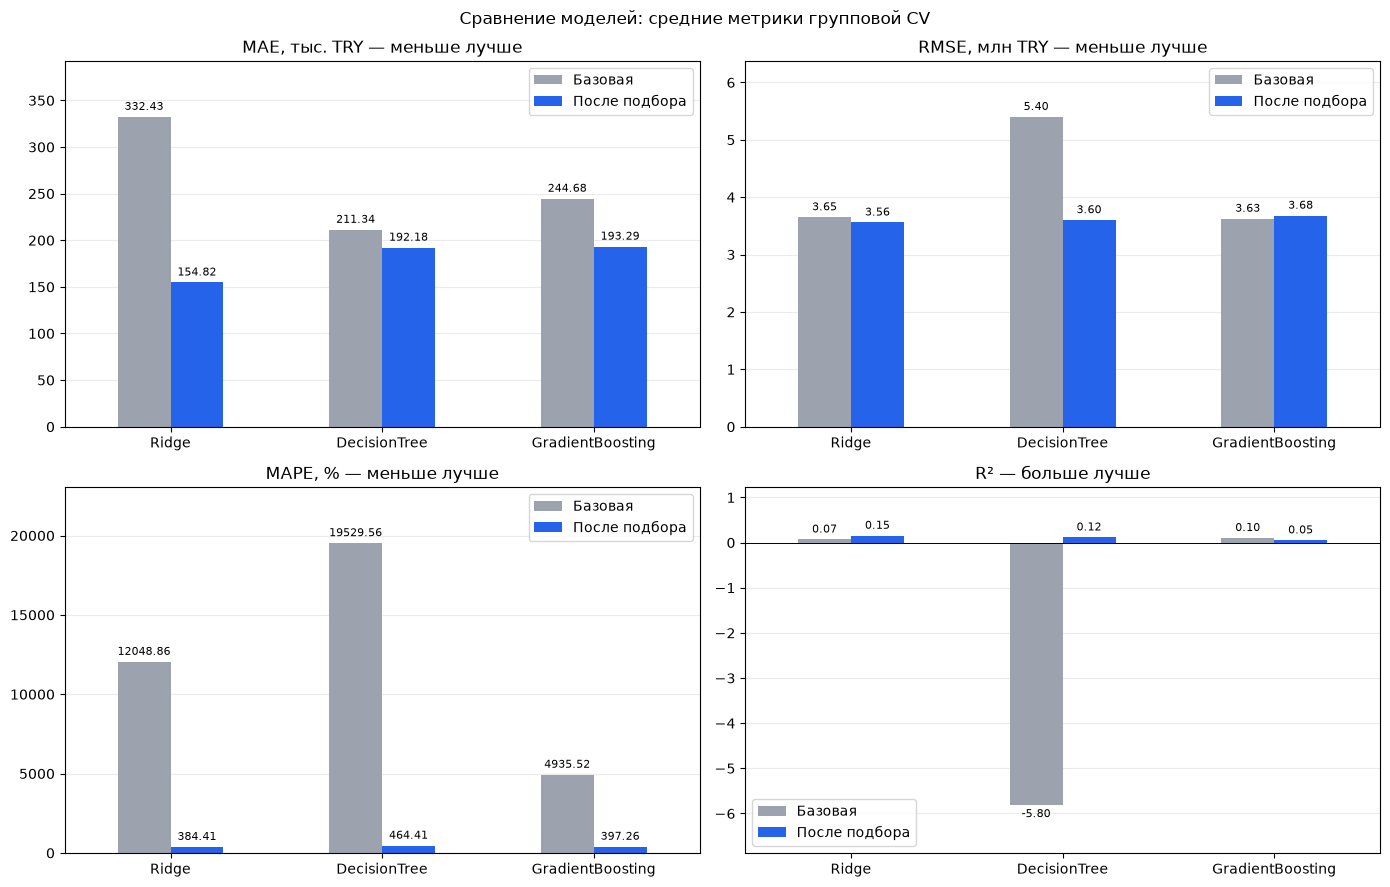

In [161]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (metric, label, scale) in zip(axes.flat, plot_settings):
    values = pd.DataFrame({
        "Базовая":
            baseline_results.loc[model_order, metric] / scale,
        "После подбора":
            tuned_results.loc[model_order, metric] / scale
    })

    values.plot.bar(
        ax=ax,
        rot=0,
        color=["#9ca3af", "#2563eb"]
    )

    ax.set_title(label)
    ax.set_xlabel("")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.margins(y=0.18)

    for bars in ax.containers:
        ax.bar_label(
            bars,
            fmt="%.2f",
            padding=3,
            fontsize=8
        )

fig.suptitle(
    "Сравнение моделей: средние метрики групповой CV"
)

plt.tight_layout()
plt.show()

In [162]:
# Предварительный лидер по прежней основной метрике
leader_name = tuned_results["MAE_CV"].idxmin()

In [163]:
diagnostic_data = pd.DataFrame({
    "Тип": X_train["listing_type"],
    "Факт": y_train,
    "Прогноз": tuned_oof[leader_name]
})

In [164]:
diagnostic_data["Остаток"] = (
    diagnostic_data["Факт"]
    - diagnostic_data["Прогноз"]
)

In [165]:
if (diagnostic_data[["Факт", "Прогноз"]] <= 0).any().any():
    raise ValueError(
        "Для логарифмических осей нужны положительные цены "
        "и прогнозы. Проверь таблицу нулевых и отрицательных "
        "прогнозов."
    )

In [166]:
listing_types = sorted(diagnostic_data["Тип"].unique())

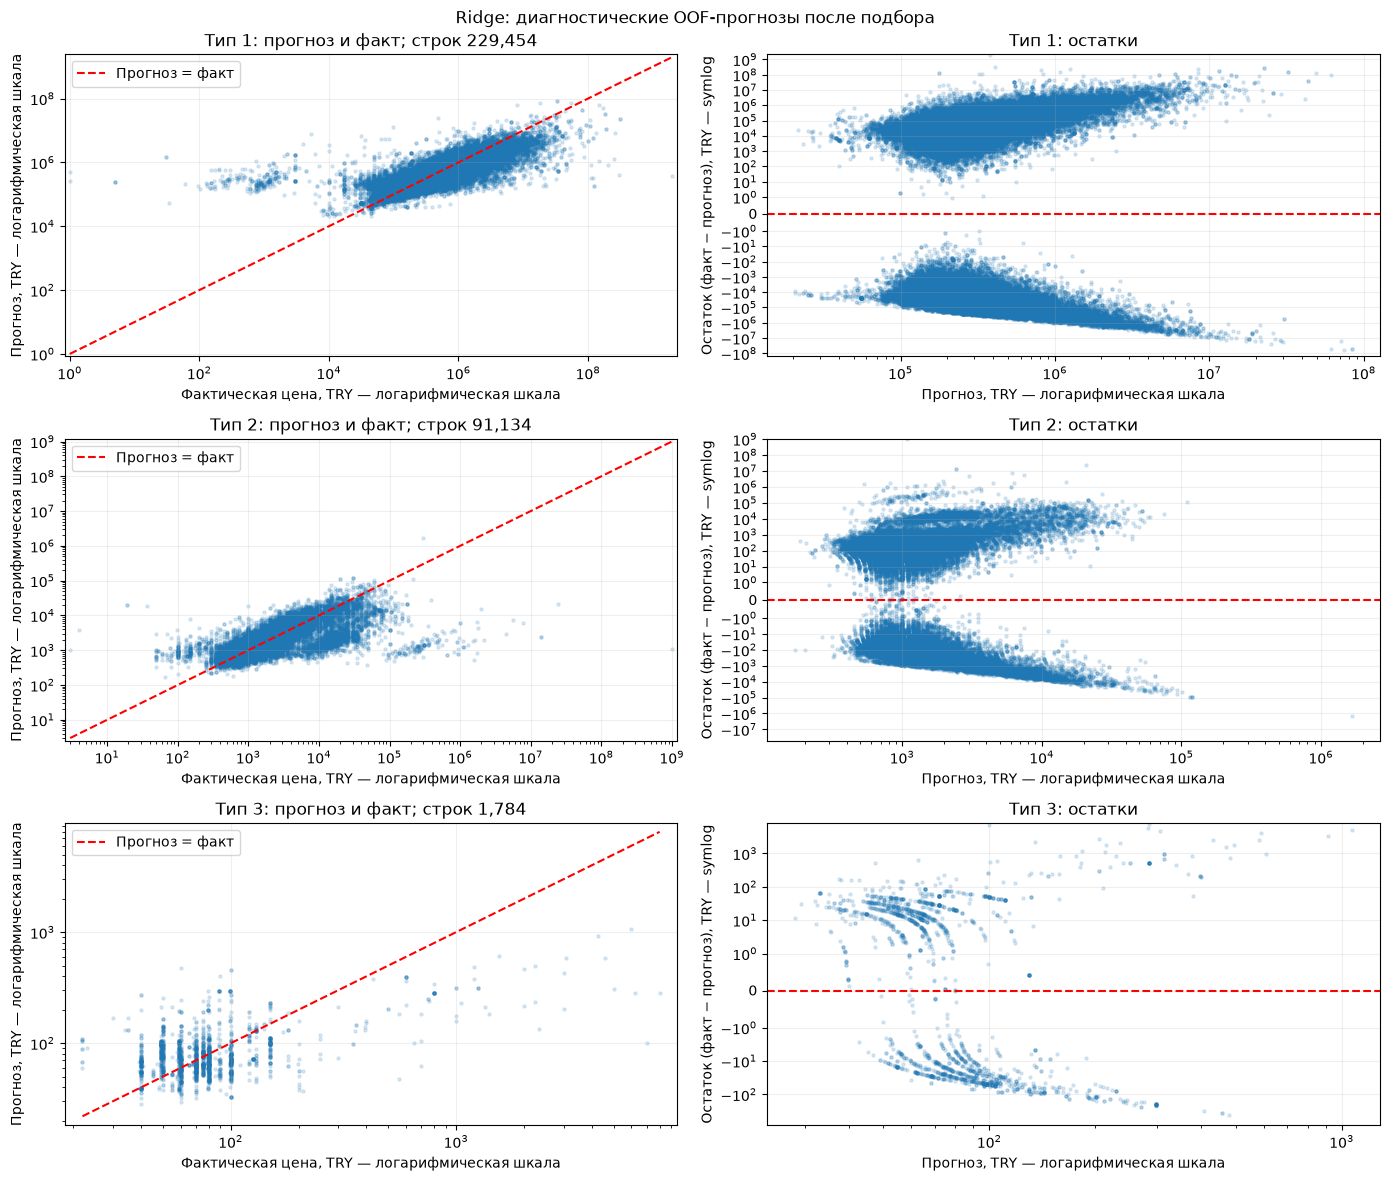

In [167]:
fig, axes = plt.subplots(
    len(listing_types),
    2,
    figsize=(14, 4 * len(listing_types)),
    squeeze=False
)

for row, listing_type in enumerate(listing_types):
    points = diagnostic_data.loc[
        diagnostic_data["Тип"].eq(listing_type)
    ]

    left, right = axes[row]

    # Фактическая цена и прогноз.
    left.scatter(
        points["Факт"],
        points["Прогноз"],
        s=5,
        alpha=0.15
    )

    low = points[["Факт", "Прогноз"]].min().min()
    high = points[["Факт", "Прогноз"]].max().max()

    left.plot(
        [low, high],
        [low, high],
        "r--",
        label="Прогноз = факт"
    )

    left.set_xscale("log")
    left.set_yscale("log")
    left.set_xlim(low / 1.2, high * 1.2)
    left.set_ylim(low / 1.2, high * 1.2)

    left.set_xlabel(
        "Фактическая цена, TRY — логарифмическая шкала"
    )
    left.set_ylabel(
        "Прогноз, TRY — логарифмическая шкала"
    )
    left.set_title(
        f"Тип {listing_type}: прогноз и факт; "
        f"строк {len(points):,}"
    )
    left.legend()

    # Остатки: факт минус прогноз.
    right.scatter(
        points["Прогноз"],
        points["Остаток"],
        s=5,
        alpha=0.15
    )

    right.axhline(0, color="red", linestyle="--")
    right.set_xscale("log")
    right.set_yscale("symlog", linthresh=1)

    right.set_xlabel(
        "Прогноз, TRY — логарифмическая шкала"
    )
    right.set_ylabel(
        "Остаток (факт − прогноз), TRY — symlog"
    )
    right.set_title(f"Тип {listing_type}: остатки")

    for ax in [left, right]:
        ax.grid(alpha=0.2)

fig.suptitle(
    f"{leader_name}: диагностические OOF-прогнозы после подбора"
)

plt.tight_layout()
plt.show()

Графики Ridge показывают, что прогнозы воспроизводят различия в ценах лишь частично. Среди объектов с высокими фактическими ценами заметны существенные недооценки, а отдельные объявления с низкими ценами получают завышенные прогнозы.

На графиках остатков наблюдаются неоднородный разброс и крупные ошибки. Следовательно, отсутствие отрицательных прогнозов само по себе не означает достаточного качества модели.

Остатки показаны в симметричной логарифмической шкале, сохраняющей отрицательные значения и ноль. Расстояния на этой шкале нелинейны, поэтому величину ошибок следует оценивать по подписям осей и числовым метрикам.

Ridge сохраняется как предварительный лидер по средней CV-MAE. Перед окончательным выбором необходимо проанализировать влияние признаков и наиболее крупные ошибки.

#### Анализ коэффициентов и важности признаков

Для интерпретации используются выбранные модели, обученные на всей обучающей выборке. Тестовая выборка в этом анализе не используется.

У Ridge рассматриваются коэффициенты при признаках после предобработки. Модель обучена на log(price_try), поэтому коэффициенты не выражают изменение цены непосредственно в лирах. Числовые признаки масштабированы, а коэффициенты One-Hot-категорий определяются относительно исключённой базовой категории. Поэтому сравнение модулей коэффициентов не является универсальным рейтингом важности исходных характеристик.

Для дерева решений и градиентного бустинга используются встроенные важности MDI, отражающие уменьшение неоднородности при построении деревьев. Важности всех закодированных категорий одной характеристики суммируются. Эти показатели описывают работу моделей и не доказывают причинного влияния признаков на стоимость.

In [168]:
feature_labels = {
    "size": "Площадь",
    "rooms_total": "Всего комнат",
    "living_rooms": "Гостиные",
    "listing_time_days": "Время публикации",
    "rooms_missing": "Неизвестная планировка",
    "listing_type": "Тип объявления",
    "sub_type": "Подтип недвижимости",
    "heating_type": "Отопление",
    "floor_no": "Этаж",
    "building_age": "Возраст здания",
    "total_floor_count": "Этажность здания",
    "address": "Адрес"
}

In [169]:
def feature_source(name):
    # Полные префиксы именно нашей предобработки.
    direct = {
        "size__size": "size",
        "rooms__rooms_total": "rooms_total",
        "rooms__living_rooms": "living_rooms",
        "time__listing_time_days": "listing_time_days",
        "binary__rooms_missing": "rooms_missing"
    }

    matches = [direct[name]] if name in direct else []

    for column in ["building_age", "total_floor_count"]:
        if name in [
            f"categories__ordinal__{column}",
            f"categories__ordinal__missingindicator_{column}"
        ]:
            matches.append(column)

    for column in [
        "listing_type", "sub_type", "heating_type", "floor_no"
    ]:
        if name.startswith(f"categories__nominal__{column}_"):
            matches.append(column)

    if name.startswith("categories__address__address_"):
        matches.append("address")

    if len(matches) != 1:
        raise ValueError(
            f"Не удалось однозначно сопоставить признак: {name}"
        )

    return matches[0]

In [170]:
def fitted_feature_table(model_name):
    wrapped = best_models[model_name]

    assert wrapped.func is np.log
    assert wrapped.inverse_func is np.exp

    fitted_pipeline = wrapped.regressor_
    fitted_preprocessor = fitted_pipeline.named_steps["preprocess"]
    fitted_model = fitted_pipeline.named_steps["model"]

    names = fitted_preprocessor.get_feature_names_out()

    assert len(names) == fitted_model.n_features_in_
    assert len(set(names)) == len(names)

    table = pd.DataFrame({
        "Признак после обработки": names
    })

    table["Признак до кодирования"] = (
        table["Признак после обработки"].map(feature_source)
    )

    return fitted_model, fitted_preprocessor, table

In [171]:
ridge_model, ridge_preprocessor, ridge_coefficients = (
    fitted_feature_table("Ridge")
)

ridge_coefficients["Коэффициент"] = (
    np.asarray(ridge_model.coef_).ravel()
)

assert np.isfinite(ridge_coefficients["Коэффициент"]).all()

ridge_coefficients["Модуль коэффициента"] = (
    ridge_coefficients["Коэффициент"].abs()
)

ridge_coefficients = ridge_coefficients.sort_values(
    "Модуль коэффициента",
    ascending=False
)

In [172]:
print("20 наибольших по модулю коэффициентов; цель — log(price_try)")
display(ridge_coefficients.head(20).round(4))

20 наибольших по модулю коэффициентов; цель — log(price_try)


,Признак после обработки,Признак до кодирования,Коэффициент,Модуль коэффициента
6,categories__nominal__listing_type_3,listing_type,-7.9769,7.9769
5,categories__nominal__listing_type_2,listing_type,-5.3846,5.3846
2417,categories__address__address_İstanbul/Şişli/Ha...,address,2.8361,2.8361
1983,categories__address__address_İstanbul/Beşiktaş...,address,2.6312,2.6312
2264,categories__address__address_İstanbul/Sarıyer/...,address,2.6013,2.6013
1991,categories__address__address_İstanbul/Beşiktaş...,address,2.5765,2.5765
2275,categories__address__address_İstanbul/Sarıyer/...,address,2.4336,2.4336
1982,categories__address__address_İstanbul/Beşiktaş...,address,2.2756,2.2756
2644,categories__address__address_İzmir/Çeşme/Celal...,address,2.2563,2.2563
1998,categories__address__address_İstanbul/Beşiktaş...,address,2.1992,2.1992


In [173]:
print("Коэффициенты остальных характеристик")
with pd.option_context("display.max_rows", None):
    display(
        ridge_coefficients.loc[
            ridge_coefficients["Признак до кодирования"].ne("address")
        ].round(4)
    )


Коэффициенты остальных характеристик


,Признак после обработки,Признак до кодирования,Коэффициент,Модуль коэффициента
6,categories__nominal__listing_type_3,listing_type,-7.9769,7.9769
5,categories__nominal__listing_type_2,listing_type,-5.3846,5.3846
9,categories__nominal__sub_type_Köşk / Konak / Yalı,sub_type,1.2818,1.2818
12,categories__nominal__sub_type_Prefabrik Ev,sub_type,-1.1368,1.1368
15,categories__nominal__sub_type_Yalı Dairesi,sub_type,0.9967,0.9967
17,categories__nominal__sub_type_Çiftlik Evi,sub_type,0.9119,0.9119
7,categories__nominal__sub_type_Komple Bina,sub_type,0.7994,0.7994
30,categories__nominal__heating_type_Soba (Kömür),heating_type,-0.5729,0.5729
4,binary__rooms_missing,rooms_missing,0.5701,0.5701
14,categories__nominal__sub_type_Villa,sub_type,0.5565,0.5565


In [174]:
# Базовые категории нужны для интерпретации One-Hot коэффициентов
nominal_fitted = (
    ridge_preprocessor
    .named_transformers_["categories"]
    .named_transformers_["nominal"]
)

reference_categories = pd.DataFrame({
    "Признак": nominal_fitted.feature_names_in_,
    "Базовая категория": [
        categories[int(drop_index)]
        for categories, drop_index in zip(
            nominal_fitted.categories_,
            nominal_fitted.drop_idx_
        )
    ]
})

display(reference_categories)

,Признак,Базовая категория
0,listing_type,1
1,sub_type,Daire
2,heating_type,Fancoil
3,floor_no,1


In [175]:
address_fitted = (
    ridge_preprocessor
    .named_transformers_["categories"]
    .named_transformers_["address"]
)

In [176]:
address_base = address_fitted.categories_[0][
    int(address_fitted.drop_idx_[0])
]

In [177]:
rare_addresses = address_fitted.infrequent_categories_[0]

In [178]:
if rare_addresses is not None and address_base in rare_addresses:
    address_base = "Группа редких адресов"

In [179]:
print("Базовая категория адреса:", address_base)

Базовая категория адреса: Adana/Kozan/Karacaoğlan


In [180]:
ridge_top = (
    ridge_coefficients.head(20)
    .sort_values("Коэффициент")
)


In [181]:
ridge_plot_labels = (
    ridge_top["Признак после обработки"]
    .str.replace(
        "categories__address__address_",
        "Адрес: ",
        regex=False
    )
    .str.replace(
        "categories__nominal__listing_type_",
        "Тип объявления: ",
        regex=False
    )
)

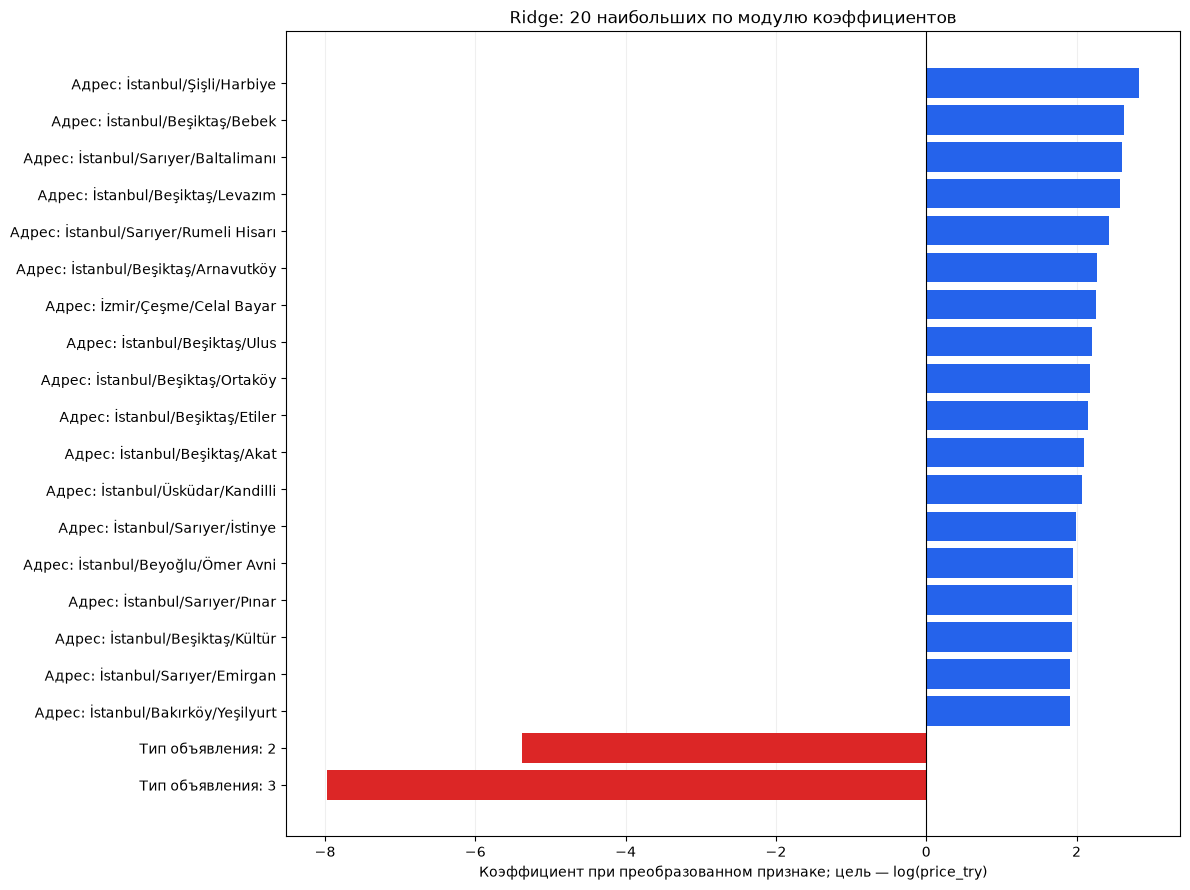

In [182]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(
    ridge_plot_labels,
    ridge_top["Коэффициент"],
    color=np.where(
        ridge_top["Коэффициент"] >= 0,
        "#2563eb",
        "#dc2626"
    )
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ridge: 20 наибольших по модулю коэффициентов")
ax.set_xlabel(
    "Коэффициент при преобразованном признаке; "
    "цель — log(price_try)"
)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Интерпретация коэффициентов Ridge**

Наибольшие по модулю коэффициенты относятся к типам объявлений 3 и 2: приблизительно −7,98 и −5,38 соответственно. Базовой категорией является тип 1. При одинаковых остальных признаках модель прогнозирует для типов 2 и 3 более низкие цены. Коэффициенты относятся к логарифму цены, поэтому их нельзя трактовать как уменьшение стоимости на соответствующее количество лир.

Среди двадцати наибольших по модулю коэффициентов также представлены адресные категории. Их коэффициенты сравниваются с базовой категорией адреса, указанной в выводе.

В таблице остальных характеристик коэффициенты преобразованной площади и общего количества комнат положительны, а коэффициент ранга возраста здания отрицателен. Это характеризует зависимость прогнозов данной модели при прочих равных. Например, коэффициент площади нельзя интерпретировать как изменение цены при увеличении площади на один квадратный метр: площадь предварительно логарифмирована и масштабирована.

Полученные зависимости описывают обученную модель. С учётом выявленных ошибок прогнозирования они не рассматриваются как доказанные закономерности рынка.

In [183]:
tree_importances = {}
grouped_importances = {}

for name in ["DecisionTree", "GradientBoosting"]:
    fitted_model, _, table = fitted_feature_table(name)

    table["Важность MDI"] = fitted_model.feature_importances_

    assert np.isfinite(table["Важность MDI"]).all()
    assert table["Важность MDI"].ge(0).all()
    assert np.isclose(table["Важность MDI"].sum(), 1)

    tree_importances[name] = table.sort_values(
        "Важность MDI",
        ascending=False
    )

    # Складываем важности всех выходов одного входного признака.
    # Например, категории адреса или ранг возраста и индикатор
    # его пропуска.
    grouped = (
        table.groupby("Признак до кодирования")["Важность MDI"]
        .sum()
    )

    assert np.isclose(
        grouped.sum(),
        table["Важность MDI"].sum()
    )

    grouped_importances[name] = grouped

    print(f"{name}: 15 самых важных признаков после обработки")
    display(tree_importances[name].head(15).round(4))

importance_by_feature = (
    pd.DataFrame(grouped_importances)
    .reindex(feature_labels)
)

assert importance_by_feature.notna().all().all()

print("Суммарная важность по признакам до кодирования, %")
display(
    (100 * importance_by_feature)
    .rename(index=feature_labels)
    .round(2)
)

DecisionTree: 15 самых важных признаков после обработки


,Признак после обработки,Признак до кодирования,Важность MDI
5,categories__nominal__listing_type_2,listing_type,0.8922
6,categories__nominal__listing_type_3,listing_type,0.0582
1,rooms__rooms_total,rooms_total,0.0215
14,categories__nominal__sub_type_Villa,sub_type,0.0046
70,categories__ordinal__total_floor_count,total_floor_count,0.0036
0,size__size,size,0.0034
13,categories__nominal__sub_type_Rezidans,sub_type,0.0015
7,categories__nominal__sub_type_Komple Bina,sub_type,0.0014
69,categories__ordinal__building_age,building_age,0.0010
3,time__listing_time_days,listing_time_days,0.0009


GradientBoosting: 15 самых важных признаков после обработки


,Признак после обработки,Признак до кодирования,Важность MDI
5,categories__nominal__listing_type_2,listing_type,0.8980
6,categories__nominal__listing_type_3,listing_type,0.0580
1,rooms__rooms_total,rooms_total,0.0181
14,categories__nominal__sub_type_Villa,sub_type,0.0061
0,size__size,size,0.0048
70,categories__ordinal__total_floor_count,total_floor_count,0.0028
13,categories__nominal__sub_type_Rezidans,sub_type,0.0015
7,categories__nominal__sub_type_Komple Bina,sub_type,0.0010
30,categories__nominal__heating_type_Soba (Kömür),heating_type,0.0005
63,categories__nominal__floor_no_Müstakil,floor_no,0.0005


Суммарная важность по признакам до кодирования, %


,DecisionTree,GradientBoosting
Признак до кодирования,,
Площадь,0.34,0.48
Всего комнат,2.15,1.81
Гостиные,0.01,0.00
Время публикации,0.09,0.00
Неизвестная планировка,0.03,0.03
Тип объявления,95.04,95.60
Подтип недвижимости,0.86,0.98
Отопление,0.21,0.15
Этаж,0.09,0.06


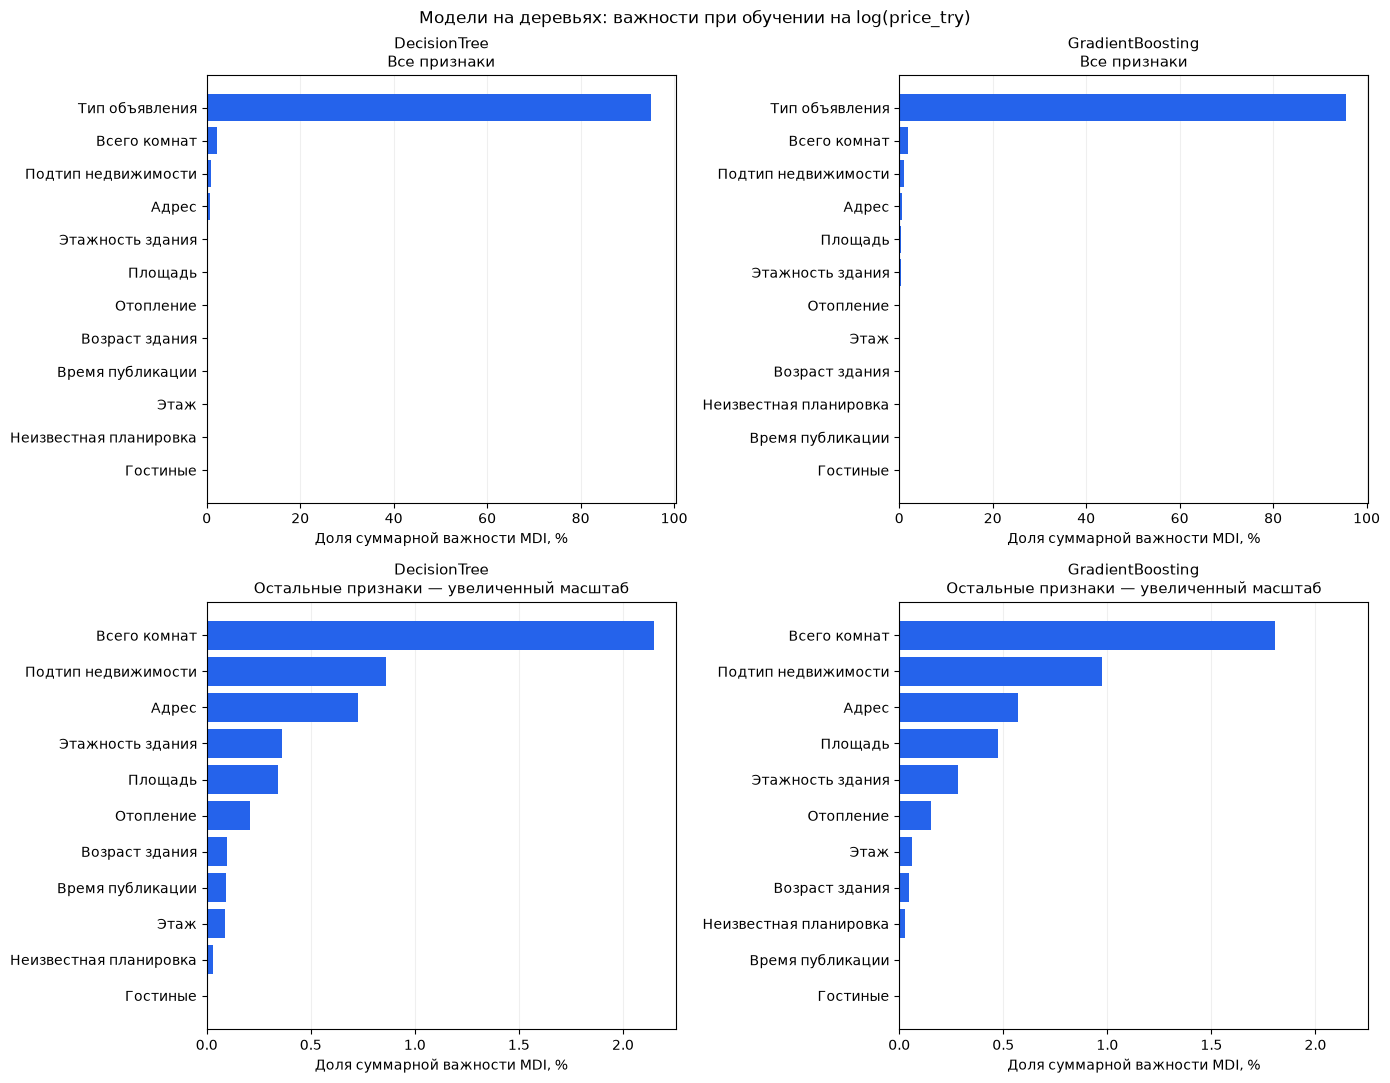

In [184]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 11),
    sharex="row"
)

for column, name in enumerate(
    ["DecisionTree", "GradientBoosting"]
):
    all_values = 100 * importance_by_feature[name]

    for row in [0, 1]:
        # Нижний ряд подробнее показывает остальные признаки.
        # Их доли сохраняются: повторной нормировки нет.
        values = (
            all_values
            if row == 0
            else all_values.drop("listing_type")
        )
        values = values.sort_values()

        ax = axes[row, column]

        ax.barh(
            values.index.map(feature_labels),
            values.values,
            color="#2563eb"
        )

        suffix = (
            "Все признаки"
            if row == 0
            else "Остальные признаки — увеличенный масштаб"
        )

        ax.set_title(f"{name}\n{suffix}", fontsize=11)
        ax.set_xlabel("Доля суммарной важности MDI, %")
        ax.grid(axis="x", alpha=0.2)
        ax.set_axisbelow(True)

fig.suptitle(
    "Модели на деревьях: важности при обучении на log(price_try)"
)

plt.tight_layout()
plt.show()

**Интерпретация важности признаков**

В обеих моделях на деревьях доминирует тип объявления: его суммарная важность составляет приблизительно 95,04% у DecisionTree и 95,60% у GradientBoosting. Это означает, что основная часть уменьшения неоднородности при построении деревьев связана с разделением типов объявлений. Это не означает, что тип объявления определяет 95% стоимости объекта или обеспечивает такую же точность прогнозирования.

Среди остальных характеристик выделяются общее количество комнат, подтип недвижимости и адрес. Их важности составляют соответственно около 2,15%, 0,86% и 0,73% у дерева решений; 1,81%, 0,98% и 0,57% у градиентного бустинга.

На нижнем ряду графиков остальные характеристики показаны в увеличенном масштабе. Их доли рассчитаны относительно общей важности всех признаков и не нормированы повторно.

Важности MDI зависят от устройства модели и могут быть смещены в пользу характеристик с большим числом возможных разбиений. Взаимосвязанные признаки также могут распределять важность между собой. Поэтому небольшая важность сама по себе не является основанием для удаления признака.

Доминирование типа объявления подтверждает необходимость оценивать качество отдельно по типам: различение общих ценовых уровней ещё не означает точного прогнозирования внутри каждой группы.

**Дополнительный анализ крупнейших ошибок** 

Для предварительного лидера Ridge исследуются ошибки по ранее полученным OOF-прогнозам обучающей выборки. Анализ проводится для всей выборки и отдельно по типам объявлений.

Для каждой строки рассчитываются:

AE - абсолютная ошибка в лирах: модуль разности фактической цены и прогноза;

SE - квадрат ошибки, используемый при расчёте RMSE;

APE - абсолютная относительная ошибка в процентах: 100 × AE / фактическая цена.

Дополнительно определяется медианная APE, позволяющая оценить центральный уровень относительных ошибок.

Для оценки концентрации ошибок рассчитываются доли десяти крупнейших значений в суммах AE, SE и APE. Десятка определяется отдельно для каждой выборки и каждого вида ошибки. Доля суммы квадратов ошибок не является долей самой RMSE.

Исходные сведения об объявлениях используются для проверки цен, валют и характеристик объектов. Выявление большой ошибки прогноза само по себе не служит основанием для удаления строки. Тестовая выборка в анализе не используется.

In [185]:
assert X_train.index.is_unique and df.index.is_unique
assert diagnostic_data.index.equals(X_train.index)
assert y_train.index.equals(X_train.index)
assert groups_train.index.equals(X_train.index)
assert tuned_oof.index.equals(X_train.index)

In [186]:
assert diagnostic_data["Тип"].equals(X_train["listing_type"])
assert np.array_equal(diagnostic_data["Факт"], y_train)
assert np.array_equal(
    diagnostic_data["Прогноз"],
    tuned_oof[leader_name]
)

In [187]:
assert np.isfinite(
    diagnostic_data[["Факт", "Прогноз"]].to_numpy()
).all()
assert diagnostic_data["Факт"].gt(0).all()

In [188]:
error_analysis = diagnostic_data.copy()

In [189]:
error_analysis["Остаток"] = (
    error_analysis["Факт"] - error_analysis["Прогноз"]
)

In [190]:
error_analysis["AE"] = error_analysis["Остаток"].abs()
error_analysis["SE"] = error_analysis["Остаток"].pow(2)
error_analysis["APE_%"] = (
    100 * error_analysis["AE"] / error_analysis["Факт"]
)

In [191]:
assert np.isfinite(
    error_analysis[["AE", "SE", "APE_%"]].to_numpy()
).all()

In [192]:
error_analysis["id"] = df.loc[error_analysis.index, "id"]
error_analysis["group_id"] = groups_train

error_analysis["Строк группы в train"] = (
    groups_train.map(groups_train.value_counts())
)


In [193]:
print(
    f"Анализируем {leader_name}: "
    f"{len(error_analysis):,} OOF-прогнозов"
)

Анализируем Ridge: 322,372 OOF-прогнозов


In [194]:
def top_error_share(values, k=10):
    total = values.sum()
    return (
        100 * values.nlargest(k).sum() / total
        if total > 0
        else np.nan
    )

In [195]:
def summarize_errors(part):
    return {
        "Количество": len(part),
        "MAE, TRY": part["AE"].mean(),
        "RMSE, TRY": np.sqrt(part["SE"].mean()),
        "MAPE, %": part["APE_%"].mean(),
        "Медиана APE, %": part["APE_%"].median(),
        "Топ-10: доля суммы AE, %": top_error_share(part["AE"]),
        "Топ-10: доля суммы SE, %": top_error_share(part["SE"]),
        "Топ-10: доля суммы APE, %": top_error_share(part["APE_%"])
    }

In [206]:
error_rows = [{
    "Выборка": "Весь train",
    **summarize_errors(error_analysis)
}]
for listing_type, part in error_analysis.groupby("Тип", sort=True):
    error_rows.append({
        "Выборка": f"Тип {listing_type}",
        **summarize_errors(part)
    })

In [198]:
error_summary = (
    pd.DataFrame(error_rows)
    .set_index("Выборка")
)

In [199]:
print("Метрики по объединённым OOF-прогнозам")
display(error_summary.iloc[:, :5].round(2))

Метрики по объединённым OOF-прогнозам


,Количество,"MAE, TRY","RMSE, TRY","MAPE, %","Медиана APE, %"
Выборка,,,,,
Весь train,322372,154807.44,4323583.66,384.35,19.40
Тип 1,229454,212119.29,4679766.72,525.30,19.03
Тип 2,91134,13538.60,3314398.45,36.10,20.32
Тип 3,1784,76.45,392.89,46.85,31.66


In [200]:
print(
    "Концентрация ошибок: доли десяти крупнейших "
    "значений в каждой выборке"
)
display(error_summary.iloc[:, 5:].round(4))

Концентрация ошибок: доли десяти крупнейших значений в каждой выборке


,"Топ-10: доля суммы AE, %","Топ-10: доля суммы SE, %","Топ-10: доля суммы APE, %"
Выборка,,,
Весь train,9.8789,90.9653,81.7064
Тип 1,8.3883,89.6513,83.9930
Тип 2,87.1837,99.9956,12.5402
Тип 3,33.2588,85.9066,5.6125


In [201]:
top_absolute_errors = error_analysis.nlargest(10, "AE")
top_relative_errors = error_analysis.nlargest(10, "APE_%")

In [202]:
detail_columns = [
    "id", "Тип", "Факт", "Прогноз", "AE", "APE_%",
    "group_id", "Строк группы в train"
]

In [203]:
detail_names = {
    "Факт": "Факт, TRY",
    "Прогноз": "Прогноз, TRY",
    "AE": "Абсолютная ошибка, TRY",
    "APE_%": "Относительная ошибка, %"
}

In [204]:
for title, table in [
    ("10 наибольших ошибок в лирах", top_absolute_errors),
    ("10 наибольших относительных ошибок", top_relative_errors)
]:
    print(title)

    with pd.option_context(
        "display.float_format",
        lambda value: f"{value:,.2f}".replace(",", " ")
    ):
        display(
            table[detail_columns].rename(columns=detail_names)
        )

10 наибольших ошибок в лирах


,id,Тип,"Факт, TRY","Прогноз, TRY","Абсолютная ошибка, TRY","Относительная ошибка, %",group_id,Строк группы в train
392156,392157,1,2 000 000 000.00,379 193.51,1 999 620 806.49,99.98,282628,2
397627,397628,2,999 999 100.00,1 092.02,999 998 007.98,100.00,294582,1
13209,13210,1,300 000 000.00,410 125.33,299 589 874.67,99.86,10552,1
369884,369885,1,310 000 000.00,22 756 869.55,287 243 130.45,92.66,273278,2
371170,371171,1,310 000 000.00,22 756 869.55,287 243 130.45,92.66,273278,2
328479,328480,1,260 000 000.00,8 515 309.38,251 484 690.62,96.72,243500,1
103704,103705,1,250 000 000.00,1 245 358.44,248 754 641.56,99.50,78829,1
1319,1320,1,200 000 000.00,818 816.80,199 181 183.20,99.59,1102,1
99412,99413,1,190 000 000.00,11 504 555.01,178 495 444.99,93.94,75535,2
112630,112631,1,190 000 000.00,11 504 555.01,178 495 444.99,93.94,75535,2


10 наибольших относительных ошибок


,id,Тип,"Факт, TRY","Прогноз, TRY","Абсолютная ошибка, TRY","Относительная ошибка, %",group_id,Строк группы в train
126061,126062,1,1.00,489 818.17,489 817.17,48 981 716.55,94660,1
233698,233699,1,1.00,266 062.75,266 061.75,26 606 174.68,174087,1
397991,397992,1,5.00,246 823.28,246 818.28,4 936 365.56,294792,3
400776,400777,1,5.00,246 823.28,246 818.28,4 936 365.56,294792,3
400780,400781,1,5.00,246 823.28,246 818.28,4 936 365.56,294792,3
370081,370082,1,30.45,1 488 157.09,1 488 126.64,4 887 677.20,273463,2
373947,373948,1,30.45,1 488 157.09,1 488 126.64,4 887 677.20,273463,2
378297,378298,1,150.00,581 018.40,580 868.40,387 245.60,279735,6
342562,342563,1,60.00,207 814.19,207 754.19,346 256.98,254232,1
401539,401540,1,175.00,581 018.40,580 843.40,331 910.52,279735,6


In [205]:
# Объединяем индексы двух списков
# Одну строку не показываем дважды
review_indices = top_absolute_errors.index.union(
    top_relative_errors.index,
    sort=False
)

source_review = df.loc[
    review_indices,
    [
        "id", "listing_type", "start_date",
        "price", "price_currency", "size",
        "room_count", "sub_type", "address"
    ]
].copy()

print(
    "Исходные данные выбранных строк; "
    "price указана в price_currency"
)

with pd.option_context(
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.float_format",
    lambda value: f"{value:,.2f}".replace(",", " ")
):
    display(source_review)

Исходные данные выбранных строк; price указана в price_currency


,id,listing_type,start_date,price,price_currency,size,room_count,sub_type,address
392156,392157,1,9/26/18,2 000 000 000.00,TRY,NaN,+,Daire,Mersin/Toroslar/Mithat Toroğlu
397627,397628,2,2/17/19,999 999 100.00,TRY,160.00,3+1,Daire,Samsun/Atakum/Mevlana
13209,13210,1,1/27/19,300 000 000.00,TRY,130.00,3+1,Daire,İstanbul/Bağcılar/Merkez
369884,369885,1,10/11/18,310 000 000.00,TRY,NaN,10+0,Köşk / Konak / Yalı,İstanbul/Üsküdar/Kandilli
371170,371171,1,10/11/18,310 000 000.00,TRY,NaN,10+0,Köşk / Konak / Yalı,İstanbul/Üsküdar/Kandilli
328479,328480,1,12/7/18,260 000 000.00,TRY,28 323.00,+,Komple Bina,İstanbul/Şişli/Mecidiyeköy
103704,103705,1,10/22/18,250 000 000.00,TRY,NaN,+,Komple Bina,Adana/Yumurtalık/Akyuva
1319,1320,1,2/26/19,200 000 000.00,TRY,140.00,+,Komple Bina,İstanbul/Fatih/Rüstem Paşa
99412,99413,1,10/11/18,190 000 000.00,TRY,NaN,5+2,Köşk / Konak / Yalı,İstanbul/Sarıyer/Yeniköy
112630,112631,1,10/11/18,190 000 000.00,TRY,NaN,5+2,Köşk / Konak / Yalı,İstanbul/Sarıyer/Yeniköy


**Вывод по анализу крупнейших ошибок**

Медианная относительная ошибка Ridge составляет около 19,40%, тогда как средняя MAPE достигает 384,35%. Десять крупнейших относительных ошибок дают около 81,71% общей суммы APE. Следовательно, средняя относительная ошибка сильно зависит от небольшого числа крайних значений.

Десять крупнейших абсолютных ошибок формируют около 90,97% суммы квадратов ошибок, но только 9,88% суммы абсолютных ошибок. Поэтому RMSE особенно чувствительна к этим строкам. Вместе с тем высокая MAE объясняется ими лишь частично.

Для типа 2 десять крупнейших квадратов ошибок составляют около 99,9956% их общей суммы. Это объясняет сочетание RMSE около 3,31 млн TRY и медианной относительной ошибки около 20,32%.

Две наибольшие абсолютные ошибки связаны с объявлениями `id = 392157` и `id = 397628`, для которых указаны цены 2 млрд TRY и 999 999 100 TRY. Эти значения присутствуют в исходном датасете в лирах, поэтому их величина не возникла при пересчёте валют.

Среди крупнейших относительных ошибок встречаются исходные цены 1 и 5 TRY, а также 5 EUR. При таких небольших фактических ценах прогнозы в сотни тысяч лир дают чрезвычайно высокую APE. Эти записи требуют проверки по первоисточнику.

Некоторые строки в списках относятся к одинаковым группам потенциальных повторов. Поэтому десять строк не обязательно соответствуют десяти различным объектам. Групповое разбиение предотвращает пересечение этих групп между обучающей и проверочной частями, однако каждая сохранённая строка продолжает участвовать в расчёте метрик.

Результаты показывают концентрацию ошибок и выделяют записи для проверки. Без подтверждения ошибочности исходных сведений строки автоматически не удаляются. Медианная APE дополняет обязательные метрики, но не отменяет проблему крупных ошибок прогнозирования.

### 3.5 Выбор финальной модели

In [207]:
from time import perf_counter

In [208]:
speed_sample = X_train.sample(
    n=min(1000, len(X_train)),
    random_state=random_state
)

In [209]:
single_requests = [
    speed_sample.iloc[[i]].copy()
    for i in range(min(10, len(speed_sample)))
]


In [210]:
speed_rows = []

for name, model in best_models.items():
    # Прогрев перед измерением
    model.predict(speed_sample)
    model.predict(single_requests[0])

    single_times, batch_times = [], []

    for _ in range(5):
        for request in single_requests:
            started = perf_counter()
            model.predict(request)
            single_times.append(
                1000 * (perf_counter() - started)
            )

        started = perf_counter()
        model.predict(speed_sample)
        batch_times.append(
            1000 * (perf_counter() - started)
        )

    speed_rows.append({
        "Модель": name,
        "Одно объявление, мс": np.median(single_times),
        "Пакет, мс": np.median(batch_times)
    })


In [211]:
prediction_speed = (
    pd.DataFrame(speed_rows).set_index("Модель")
)

In [212]:
selection_table = tuned_results[
    ["MAE_CV", "MAE_CV_std", "MAE_train"]
].join(prediction_speed)


In [213]:
selection_table["Разрыв CV/train, %"] = (
    100 * (
        selection_table["MAE_CV"]
        / selection_table["MAE_train"] - 1
    )
)

In [214]:
print(
    f"Размер пакета для измерения скорости: "
    f"{len(speed_sample)} строк"
)
display(selection_table.round(3))

Размер пакета для измерения скорости: 1000 строк


,MAE_CV,MAE_CV_std,MAE_train,"Одно объявление, мс","Пакет, мс","Разрыв CV/train, %"
Модель,,,,,,
Ridge,154819.708,13805.515,151745.897,73.080,93.072,2.026
DecisionTree,192183.965,13097.560,171862.060,61.420,68.613,11.825
GradientBoosting,193288.019,13356.238,192664.243,61.896,83.901,0.324


In [215]:
# Фиксируем выбор до оценки на test
final_model_name = "Ridge"

In [216]:
assert tuned_results["MAE_CV"].idxmin() == final_model_name

In [217]:
final_model = best_models[final_model_name]

In [218]:
assert final_model.regressor_.named_steps["model"].alpha == 0.1
assert final_model.func is np.log
assert final_model.inverse_func is np.exp

In [219]:
print("Выбрана Ridge с alpha=0.1 и обучением на log(price_try)")

Выбрана Ridge с alpha=0.1 и обучением на log(price_try)


**Обоснование выбора финальной модели**

Для дальнейшего использования в учебном приложении выбрана Ridge с `alpha=0.1`, обученная на натуральном логарифме цены.

Основной критерий выбора — минимальная средняя MAE групповой кросс-валидации: около 154 820 TRY против 192 184 TRY у дерева решений и 193 288 TRY у градиентного бустинга.

Средняя ошибка Ridge на обучающих частях составляет около 151 746 TRY. Разрыв между обучением и валидацией равен приблизительно 2,03%. Это указывает на небольшой разрыв в рамках выбранной схемы проверки, хотя само по себе не гарантирует устойчивости на любых новых данных.

Скорость прогнозирования сопоставима с остальными рассмотренными моделями. Для оценки использованы медианные времена повторных измерений на одинаковых данных. В измерение включена встроенная предобработка, но не работа будущего интерфейса приложения.

Дополнительное преимущество Ridge - возможность интерпретировать коэффициенты с учётом кодирования и масштабирования признаков. При этом ранее выявленные крупные ошибки сохраняются как ограничение модели.

Выбор зафиксирован по результатам train и кросс-валидации. Отложенная тестовая выборка используется далее для итоговой оценки выбранной конфигурации.

In [220]:
assert X_test.index.equals(y_test.index)
assert X_test.index.equals(groups_test.index)
assert list(X_test.columns) == list(X_train.columns)


In [221]:
assert X_train.index.intersection(X_test.index).empty
assert set(groups_train).isdisjoint(set(groups_test))


In [222]:
assert np.isfinite(y_test).all()
assert y_test.gt(0).all()

In [223]:
test_predictions = pd.Series(
    final_model.predict(X_test),
    index=X_test.index,
    name="Прогноз, TRY"
)

C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


In [224]:
assert np.isfinite(test_predictions).all()

In [225]:
test_rows = [{
    "Выборка": "Весь test",
    "Количество": len(y_test),
    **regression_metrics(y_test, test_predictions)
}]

for listing_type in sorted(X_test["listing_type"].unique()):
    mask = X_test["listing_type"].eq(listing_type)

    test_rows.append({
        "Выборка": f"Тип {listing_type}",
        "Количество": int(mask.sum()),
        **regression_metrics(
            y_test.loc[mask],
            test_predictions.loc[mask]
        )
    })

In [226]:
test_results = (
    pd.DataFrame(test_rows).set_index("Выборка")
)

In [227]:
display(
    test_results.round({
        "MAE": 2,
        "RMSE": 2,
        "MAPE_%": 2,
        "R2": 6
    })
)

,Количество,MAE,RMSE,MAPE_%,R2
Выборка,,,,,
Весь test,80355,164761.27,6028162.29,799.39,0.079577
Тип 1,56938,222585.39,6821600.35,1111.39,0.085733
Тип 2,22967,24635.53,3431453.05,40.73,-0.000044
Тип 3,450,45.76,146.55,42.35,0.226889


In [228]:
print(
    "Нулевых прогнозов:",
    int(test_predictions.eq(0).sum())
)
print(
    "Отрицательных прогнозов:",
    int(test_predictions.lt(0).sum())
)

assert test_predictions.gt(0).all()

Нулевых прогнозов: 0
Отрицательных прогнозов: 0


**Результаты итоговой проверки**

На отложенной тестовой выборке из 80 355 объявлений Ridge получила MAE около 164 761 TRY, RMSE около 6,03 млн TRY, MAPE около 799,39% и R² около 0,0796. Нулевых и отрицательных прогнозов нет.

Качество существенно различается между типами объявлений. Для типа 1 MAE составляет около 222 585 TRY, а MAPE достигает 1111,39%. Для типа 2 MAE равна примерно 24 636 TRY, MAPE - 40,73%, а R² практически нулевой и слегка отрицательный: −0,000044. Для типа 3 MAE составляет около 45,76 TRY, MAPE - 42,35%, R² - 0,2269.

Итоговая проверка подтверждает наличие существенных ограничений качества. Отсутствие отрицательных прогнозов не означает достаточной точности, а результаты по одной группе нельзя распространять на остальные.

Ridge сохраняется как модель, выбранная по кросс-валидации для учебной демонстрации. Полученные показатели не позволяют заявлять о надёжной оценке рыночной стоимости. Ограничения необходимо отразить в справке приложения.

Тестовые результаты не используются для повторного выбора гиперпараметров, удаления неудобных наблюдений или изменения предобработки.

In [229]:
from pathlib import Path
import importlib.util
import json
import platform
from importlib.metadata import version
import joblib


In [230]:
artifact_dir = Path("artifacts").resolve()
artifact_dir.mkdir(parents=True, exist_ok=True)

In [236]:
feature_preparation_source = r'''
import numpy as np
import pandas as pd
RAW_COLUMNS = [
    "size", "room_count", "start_date", "listing_type", "sub_type",
    "heating_type", "floor_no", "building_age", "total_floor_count", "address"
]
MODEL_COLUMNS = [
    "size", "rooms_total", "living_rooms", "listing_time_days", "rooms_missing",
    "listing_type", "sub_type", "heating_type", "floor_no", "building_age",
    "total_floor_count", "address"
]
def prepare_features(raw):
    # size и listing_type — числовые; категории — исходные строки
    # start_date имеет формат %m/%d/%y, например "2/17/19"
    result = raw.loc[:, RAW_COLUMNS].copy()

    missing_columns = [
        "building_age", "total_floor_count", "floor_no",
        "heating_type", "room_count"
    ]
    result[missing_columns] = (
        result[missing_columns].fillna("Не указано")
    )

    result["size"] = (
        pd.to_numeric(result["size"], errors="raise").astype(float)
    )
    invalid_size = (
        result["size"].le(0) | ~np.isfinite(result["size"])
    )
    result.loc[invalid_size, "size"] = np.nan

    room_parts = (
        result["room_count"].astype("string")
        .str.extract(r"^\s*(\d+)\s*\+\s*(\d+)\s*$")
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
    )

    result["rooms_total"] = room_parts[0] + room_parts[1]
    result["living_rooms"] = room_parts[1]

    invalid_rooms = (
        room_parts.isna().any(axis=1)
        | result["rooms_total"].le(0)
    )

    result.loc[
        invalid_rooms,
        ["rooms_total", "living_rooms"]
    ] = np.nan

    result["rooms_missing"] = invalid_rooms.astype("int8")

    dates = pd.to_datetime(
        result["start_date"],
        format="%m/%d/%y",
        errors="raise"
    )

    result["listing_time_days"] = (
        dates - pd.Timestamp("2018-01-01")
    ).dt.days

    return result.loc[:, MODEL_COLUMNS]
'''

In [237]:
feature_module_path = artifact_dir / "feature_preparation.py"

In [238]:
feature_module_path.write_text(
    feature_preparation_source.strip() + "\n",
    encoding="utf-8"
)

1865

In [239]:
spec = importlib.util.spec_from_file_location(
    "feature_preparation",
    feature_module_path
)

In [240]:
feature_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(feature_module)

In [241]:
assert feature_module.MODEL_COLUMNS == list(X_train.columns)

In [242]:
# Проверяем совпадение с прежней подготовкой данных
export_probe = X_train.sample(
    n=min(100, len(X_train)),
    random_state=random_state
)

raw_probe = df.loc[
    export_probe.index,
    feature_module.RAW_COLUMNS
]

prepared_probe = feature_module.prepare_features(raw_probe)

pd.testing.assert_frame_equal(
    prepared_probe,
    export_probe,
    check_dtype=False
)

In [243]:
package_versions = {
    package: version(package)
    for package in [
        "numpy", "pandas", "scipy", "scikit-learn", "joblib"
    ]
}

In [244]:
train_dates = pd.to_datetime(
    df.loc[X_train.index, "start_date"],
    format="%m/%d/%y"
)


In [245]:
model_metadata = {
    "schema_version": 1,
    "model_name": final_model_name,
    "alpha": float(
        final_model.regressor_.named_steps["model"].alpha
    ),
    "target": "price_try",
    "prediction_currency": "TRY",
    "target_transform": "log; inverse: exp",
    "feature_columns": list(X_train.columns),
    "raw_columns": feature_module.RAW_COLUMNS,
    "feature_module": "feature_preparation.py",
    "date_format": "%m/%d/%y",
    "date_origin": "2018-01-01",
    "training_date_range": [
        str(train_dates.min().date()),
        str(train_dates.max().date())
    ],
    "random_state": random_state,
    "python_version": platform.python_version(),
    "package_versions": package_versions,
    "cv_metrics": tuned_results.loc[final_model_name].to_dict(),
    "test_metrics": test_results.to_dict(orient="index"),
    "prediction_speed": (
        prediction_speed.loc[final_model_name].to_dict()
    ),
    "prediction_batch_size": len(speed_sample)
}


In [246]:
model_bundle = {
    "model": final_model,
    "metadata": model_metadata
}

In [247]:
model_path = artifact_dir / "price_model.joblib"


In [248]:
joblib.dump(
    model_bundle,
    model_path,
    compress=3
)

['C:\\Users\\polin\\Downloads\\artifacts\\price_model.joblib']

In [249]:
(artifact_dir / "model_metadata.json").write_text(
    json.dumps(
        model_metadata,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

(artifact_dir / "requirements_model.txt").write_text(
    "\n".join(
        f"{name}=={value}"
        for name, value in package_versions.items()
    ) + "\n",
    encoding="utf-8"
)

75

In [250]:
# Загружаем сохранённую модель и сравниваем прогнозы
loaded_bundle = joblib.load(model_path)

In [251]:
expected_predictions = final_model.predict(export_probe)

In [252]:
restored_predictions = (
    loaded_bundle["model"].predict(prepared_probe)
)

In [253]:
np.testing.assert_allclose(
    restored_predictions,
    expected_predictions,
    rtol=1e-12,
    atol=1e-8
)

In [254]:
print(
    "Проверка пройдена: подготовка признаков "
    "и прогнозы после загрузки совпадают."
)

print("Сохранённые файлы:")

for filename in [
    "price_model.joblib",
    "feature_preparation.py",
    "model_metadata.json",
    "requirements_model.txt"
]:
    print(artifact_dir / filename)

Проверка пройдена: подготовка признаков и прогнозы после загрузки совпадают.
Сохранённые файлы:
C:\Users\polin\Downloads\artifacts\price_model.joblib
C:\Users\polin\Downloads\artifacts\feature_preparation.py
C:\Users\polin\Downloads\artifacts\model_metadata.json
C:\Users\polin\Downloads\artifacts\requirements_model.txt


**Сохранение модели и воспроизводимость**

Финальная модель сохранена вместе со всей обученной предобработкой: заполнением пропусков, кодированием категорий и масштабированием. Сохранено также обратное преобразование прогнозов из логарифмической шкалы в TRY.

Созданы четыре файла:

- `price_model.joblib` - обученная модель и метаданные;
- `feature_preparation.py` - подготовка десяти исходных характеристик к двенадцати входным признакам модели;
- `model_metadata.json` - сведения о модели, признаках, периоде данных, метриках и окружении;
- `requirements_model.txt` - версии библиотек для загрузки и применения модели.

Проверено совпадение подготовленных признаков с соответствующими строками обучающей выборки. После сохранения и загрузки модель воспроизводит прежние прогнозы.

Для переноса модели используется совместимое окружение с зафиксированными версиями библиотек.